
# PINN - Caso BFS Driver & Seegmiller

Uma PINN híbrida consegue corrigir soluções RANS coarse para aproximá-las de uma solução fine?

Específico: Quanto a incorporação de restrições físicas melhora uma rede neural simples na correção coarse→fine de soluções RANS para o problema BFS?

## Imports e configs globais

In [2]:
# Inicializa as bibliotecas necessárias
import re
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib

# Define os caminhos dos diretórios
PATH_DIR = Path.cwd().parent  # diretório atual
PATH_DF = PATH_DIR / 'data' # origem para salvar os dados do estudo
PATH_CFD = PATH_DF / 'cfd_rans_k_epsilon' # diretório dos dados CFD
PATH_DATA = PATH_DF / 'data_processed' #diretório para salvar os dados processados
PATH_OUT = PATH_DIR / 'results' # diretório para salvar os resultados
PATH_PLOT = PATH_OUT / 'plots' # diretório para salvar as plotagens
PATH_MODEL = PATH_OUT / 'models' # diretório para salvar o modelo treinado
PATH_METRIC = PATH_OUT / 'metrics' # diretório para salvar as plotagens
print(PATH_DIR)
print(PATH_CFD)
print(PATH_DATA)
print(PATH_PLOT)
print(PATH_MODEL)
print(PATH_METRIC)

/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller/data/cfd_rans_k_epsilon
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller/data/data_processed
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller/results/plots
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller/results/models
/home/matheus/Documentos/Mestrado/Dissertação/Pesquisa/lab_experimentos/pinn_bfs_driver_seegmiller/results/metrics


## Preparação dos Dataset com os dados CFD
- Aqui preparamos o dataset que será utilizado no treinamento da PINN, com a diferença entre a malha coarse(grosseira) e a fine(refinada), para que assim a rede aprenda justamente a correção delta.

### BASE Features

In [3]:
# -------------------------------------------------
# Utilidades
# -------------------------------------------------

def latest_dir(base: Path) -> Path:
    """Retorna o diretório do último 'tempo'."""
    times = sorted(
        [p for p in base.iterdir() if p.is_dir()],
        key=lambda p: float(p.name)
    )
    return times[-1]


def read_grid_file(path: Path) -> pd.DataFrame:
    """
    Lê o arquivo grid_pinn_epsilon_k_nut_p_U.xy no formato:
    x y z epsilon k nut p Ux Uy Uz
    """
    rows = []
    num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or line.startswith("//"):
                continue

            nums = num_re.findall(line)
            if len(nums) < 10:
                continue

            x, y, z, epsilon, k, nut, p, ux, uy, uz = map(float, nums[:10])
            rows.append((x, y, z, epsilon, k, nut, p, ux, uy, uz))

    return pd.DataFrame(
        rows, columns=["x", "y", "z", "epsilon", "k", "nut", "p", "Ux", "Uy", "Uz"]
    )


def load_case(case_dir: str) -> pd.DataFrame:
    """
    Carrega o grid_pinn_epsilon_k_nut_p_U.xy do último tempo do caso.
    """
    case = Path(case_dir)
    tdir = latest_dir(case)

    fpath = tdir / "grid_pinn_epsilon_k_nut_p_U.xy"
    if not fpath.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {fpath}")

    return read_grid_file(fpath)

# -------------------------------------------------
# Main
# -------------------------------------------------

print("Lendo caso coarse...")
dfc = load_case(PATH_CFD / "coarse")

print("Lendo caso fine...")
dff = load_case(PATH_CFD / "fine")

# Merge ponto a ponto (x,y)
df = dfc.merge(
    dff[["x", "y", "epsilon", "k", "nut", "p", "Ux", "Uy"]].rename(
        columns={
            "p": "p_f",
            "Ux": "Ux_f",
            "Uy": "Uy_f",
            "epsilon": "epsilon_f",
            "k": "k_f",
            "nut": "nut_f"
        }
    ),
    on=["x", "y"],
    how="inner"
)

# Erro coarse -> fine (targets do ML)
df["dUx"] = df["Ux_f"] - df["Ux"]
df["dUy"] = df["Uy_f"] - df["Uy"]
df["dp"]  = df["p_f"]  - df["p"]
df["depsilon"] = df["epsilon_f"] - df["epsilon"]
df["dk"] = df["k_f"] - df["k"]
df["dnut"] = df["nut_f"] - df["nut"]
df["nut_log"] = np.log10(df["nut"] + 1e-12)  # log(nut) para ML

# Reynolds (fixo neste experimento)
df["Re"] = 36000.0

# Dataset final
out = df[[
    "x", "y",
    "Ux", "Uy", "p", "epsilon", "k", "nut_log",
    "Re",
    "dUx", "dUy", "dp", "depsilon", "dk", "dnut"
]].copy()
out_name = "dataset_bfs_2d_kepsilon.parquet"
out.to_parquet(PATH_DATA / out_name, index=False)
print(f"Dataset salvo em: {out_name}")
print("Total de amostras:", len(out))

Lendo caso coarse...
Lendo caso fine...
Dataset salvo em: dataset_bfs_2d_kepsilon.parquet
Total de amostras: 100975


In [4]:
df=pd.read_parquet(PATH_DATA / "dataset_bfs_2d_kepsilon.parquet")
df.head()

,x,y,Ux,Uy,p,epsilon,k,nut_log,Re,dUx,dUy,dp,depsilon,dk,dnut
0,0.002800,0.0,0.0,0.0,16.30860,126644.0,1.46918,-1.561923,36000.0,0.0,0.0,-654.40860,-9.929130e+04,-1.250487,-0.025904
1,0.007381,0.0,0.0,0.0,3.10882,564753.0,4.05172,-9.045664,36000.0,0.0,0.0,-661.40682,2.086070e+05,-2.010220,0.002724
2,0.011962,0.0,0.0,0.0,7.10518,811732.0,5.09731,-2.230671,36000.0,0.0,0.0,-670.99518,1.382518e+06,-1.004610,-0.005241
3,0.016543,0.0,0.0,0.0,39.53730,159728000.0,138.11800,-2.548872,36000.0,0.0,0.0,-689.56030,-1.597215e+08,-138.035866,-0.001307
4,0.021124,0.0,0.0,0.0,83.79700,256150.0,2.38642,-2.888029,36000.0,0.0,0.0,-753.86000,-2.523631e+05,-2.328312,-0.000018


In [5]:
df.describe()

,x,y,Ux,Uy,p,epsilon,k,nut_log,Re,dUx,dUy,dp,depsilon,dk,dnut
count,100975.000000,100975.000000,100975.000000,100975.000000,100975.000000,1.009750e+05,1.009750e+05,100975.000000,100975.0,100975.000000,100975.000000,100975.000000,1.009750e+05,100975.000000,1.009750e+05
mean,-0.479543,0.061698,42.554235,-0.110870,132.558009,1.914596e+04,1.103570e+01,-5.158847,36000.0,0.037372,-0.001901,-68.738597,6.348742e+04,0.124928,-2.256255e-03
std,0.667885,0.030716,8.310754,0.624127,71.387386,6.533074e+05,1.919407e+01,3.499228,0.0,8.851780,4.001391,338.152735,7.097039e+06,26.687948,8.090819e-03
min,-1.651000,0.000000,-12.701400,-5.877700,-83.634600,8.762990e-08,1.243070e-09,-11.602105,36000.0,-63.255400,-36.210663,-2376.377700,-1.597215e+08,-138.035866,-4.021881e-02
25%,-1.060030,0.035490,41.382900,-0.067909,77.818300,2.420570e-02,7.637845e-05,-8.391590,36000.0,-2.222150,-0.518783,-329.038100,-1.111784e+02,-2.747479,-1.923299e-03
50%,-0.469060,0.062108,45.445200,-0.002989,118.866000,9.633100e+01,8.828560e-01,-3.275329,36000.0,0.822600,-0.002637,-1.195000,-1.921661e-04,-0.000002,-1.221755e-09
75%,0.112747,0.088204,47.220900,0.057166,185.413500,3.348915e+03,1.329345e+01,-2.336258,36000.0,3.117400,0.496151,236.246000,1.107007e+03,2.122057,1.747002e-04
max,0.635000,0.114300,51.277500,4.283060,276.816000,1.597280e+08,1.381180e+02,-1.390376,36000.0,38.851900,42.526200,356.641000,1.640644e+09,426.098400,8.091608e-02


### BASE + Vorticidade(WZ)

In [73]:
# -------------------------------------------------
# Utilidades
# -------------------------------------------------

def latest_dir(base: Path) -> Path:
    """Retorna o diretório do último 'tempo'."""
    times = sorted(
        [p for p in base.iterdir() if p.is_dir()],
        key=lambda p: float(p.name)
    )
    return times[-1]


def read_grid_file(path: Path) -> pd.DataFrame:
    """
    Lê o arquivo grid_pinn_epsilon_k_nut_p_U.xy no formato:
    x y z epsilon k nut p Ux Uy Uz
    """
    rows = []
    num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#") or line.startswith("//"):
                continue

            nums = num_re.findall(line)
            if len(nums) < 10:
                continue

            x, y, z, epsilon, k, nut, p, ux, uy, uz = map(float, nums[:10])
            rows.append((x, y, z, epsilon, k, nut, p, ux, uy, uz))

    return pd.DataFrame(
        rows, columns=["x", "y", "z", "epsilon", "k", "nut", "p", "Ux", "Uy", "Uz"]
    )


def load_case(case_dir: str) -> pd.DataFrame:
    """
    Carrega o grid_pinn_epsilon_k_nut_p_U.xy do último tempo do caso.
    """
    case = Path(case_dir)
    tdir = latest_dir(case)

    fpath = tdir / "grid_pinn_epsilon_k_nut_p_U.xy"
    if not fpath.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {fpath}")

    return read_grid_file(fpath)

def add_vorticity_from_grid(df, ux_col="Ux", uy_col="Uy", name="wz"):
    df = df.sort_values(["y", "x"]).copy()

    xs = np.sort(df["x"].unique())
    ys = np.sort(df["y"].unique())

    Ux_grid = df.pivot(index="y", columns="x", values=ux_col).reindex(index=ys, columns=xs)
    Uy_grid = df.pivot(index="y", columns="x", values=uy_col).reindex(index=ys, columns=xs)

    dx = np.mean(np.diff(xs))
    dy = np.mean(np.diff(ys))

    du_dy, du_dx = np.gradient(Ux_grid.values, dy, dx)
    dv_dy, dv_dx = np.gradient(Uy_grid.values, dy, dx)

    wz_grid = dv_dx - du_dy

    wz_df = (
        pd.DataFrame(wz_grid, index=ys, columns=xs)
        .stack()
        .reset_index()
    )
    wz_df.columns = ["y", "x", name]

    return df.merge(wz_df, on=["x", "y"], how="left")
# -------------------------------------------------
# Main
# -------------------------------------------------

print("Lendo caso coarse...")
dfc = load_case(PATH_CFD / "coarse")

print("Lendo caso fine...")
dff = load_case(PATH_CFD / "fine")

# Merge ponto a ponto (x,y)
df = dfc.merge(
    dff[["x", "y", "epsilon", "k", "nut", "p", "Ux", "Uy"]].rename(
        columns={
            "p": "p_f",
            "Ux": "Ux_f",
            "Uy": "Uy_f",
            "epsilon": "epsilon_f",
            "k": "k_f",
            "nut": "nut_f"
        }
    ),
    on=["x", "y"],
    how="inner"
)

# Erro coarse -> fine (targets do ML)
df["dUx"] = df["Ux_f"] - df["Ux"]
df["dUy"] = df["Uy_f"] - df["Uy"]
df["dp"]  = df["p_f"]  - df["p"]
df["depsilon"] = df["epsilon_f"] - df["epsilon"]
df["dk"] = df["k_f"] - df["k"]

# Calculando a vorticidade
df = add_vorticity_from_grid(df, ux_col="Ux", uy_col="Uy", name="wz")
df = add_vorticity_from_grid(df, ux_col="Ux_f", uy_col="Uy_f", name="wz_f")
df["dwz"] = df["wz_f"] - df["wz"]
df = df.dropna(subset=["wz"]).reset_index(drop=True)
df["wz_log"] = np.sign(df["wz"]) * np.log1p(np.abs(df["wz"]))

# Normalizando a viscosidade turbulenta com LOG
df["dnut"] = df["nut_f"] - df["nut"]
df["nut_log"] = np.log10(df["nut"] + 1e-12)  # log(nut) para ML

# Reynolds (fixo neste experimento)
df["Re"] = 36000.0

# Dataset final
out = df[[
    "x", "y",
    "Ux", "Uy", "p", "epsilon", "k", "nut_log", "wz_log",
    "Re",
    "dUx", "dUy", "dp", "depsilon", "dk", "dnut", "dwz"
]].copy()
out_name = "dataset_bfs_2d_kepsilon_with_wz.parquet"
out.to_parquet(PATH_DATA / out_name, index=False)
print(f"Dataset salvo em: {out_name}")
print("Total de amostras:", len(out))

Lendo caso coarse...
Lendo caso fine...
Dataset salvo em: dataset_bfs_2d_kepsilon_with_wz.parquet
Total de amostras: 100589


In [74]:
df_v2 =pd.read_parquet(PATH_DATA / "dataset_bfs_2d_kepsilon_with_wz.parquet")
df_v2.head()

,x,y,Ux,Uy,p,epsilon,k,nut_log,wz_log,Re,dUx,dUy,dp,depsilon,dk,dnut,dwz
0,0.007381,0.0,0.0,0.0,3.10882,564753.0,4.05172,-9.045664,9.130015,36000.0,0.0,0.0,-661.40682,2.086070e+05,-2.010220,0.002724,-7371.756509
1,0.011962,0.0,0.0,0.0,7.10518,811732.0,5.09731,-2.230671,9.071456,36000.0,0.0,0.0,-670.99518,1.382518e+06,-1.004610,-0.005241,-17395.076115
2,0.016543,0.0,0.0,0.0,39.53730,159728000.0,138.11800,-2.548872,8.347685,36000.0,0.0,0.0,-689.56030,-1.597215e+08,-138.035866,-0.001307,-19440.417323
3,0.021124,0.0,0.0,0.0,83.79700,256150.0,2.38642,-2.888029,-7.161390,36000.0,0.0,0.0,-753.86000,-2.523631e+05,-2.328312,-0.000018,7353.464357
4,0.025705,0.0,0.0,0.0,116.91100,290501.0,2.59393,-2.816400,-8.706952,36000.0,0.0,0.0,-847.26200,-2.072508e+05,-2.130840,-0.000088,4222.107323


In [75]:
# Validando wz nan
print(df_v2["wz_log"].isna().sum())
print(df_v2["wz_log"].isna().mean()*100)

df_v2.info()

0
0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100589 entries, 0 to 100588
Data columns (total 17 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   x         100589 non-null  float64
 1   y         100589 non-null  float64
 2   Ux        100589 non-null  float64
 3   Uy        100589 non-null  float64
 4   p         100589 non-null  float64
 5   epsilon   100589 non-null  float64
 6   k         100589 non-null  float64
 7   nut_log   100589 non-null  float64
 8   wz_log    100589 non-null  float64
 9   Re        100589 non-null  float64
 10  dUx       100589 non-null  float64
 11  dUy       100589 non-null  float64
 12  dp        100589 non-null  float64
 13  depsilon  100589 non-null  float64
 14  dk        100589 non-null  float64
 15  dnut      100589 non-null  float64
 16  dwz       100589 non-null  float64
dtypes: float64(17)
memory usage: 13.0 MB


In [76]:
df_v2.describe()

,x,y,Ux,Uy,p,epsilon,k,nut_log,wz_log,Re,dUx,dUy,dp,depsilon,dk,dnut,dwz
count,100589.000000,100589.000000,100589.000000,100589.000000,100589.00000,1.005890e+05,1.005890e+05,100589.000000,100589.000000,100589.0,100589.000000,100589.000000,100589.000000,1.005890e+05,100589.000000,1.005890e+05,100589.000000
mean,-0.478418,0.061887,42.631602,-0.111983,132.48125,1.897008e+04,1.101809e+01,-5.165634,0.189513,36000.0,0.092152,-0.000279,-69.100853,6.358677e+04,0.111541,-2.264079e-03,-131.770521
std,0.668186,0.030623,8.215803,0.623290,71.37803,6.545514e+05,1.922742e+01,3.504135,4.876796,0.0,8.791259,4.007213,338.211988,7.110636e+06,26.714145,8.104834e-03,3275.023396
min,-1.651000,0.000000,-12.701400,-5.877700,-83.63460,8.762990e-08,1.243070e-09,-11.602105,-10.642070,36000.0,-63.255400,-36.210663,-2376.377700,-1.597215e+08,-138.035866,-4.021881e-02,-104296.115486
25%,-1.060030,0.036012,41.501800,-0.068360,77.77880,2.321130e-02,7.489320e-05,-8.406664,-4.488154,36000.0,-2.168500,-0.521555,-329.268500,-1.022123e+02,-2.667495,-1.986826e-03,-233.473924
50%,-0.464479,0.062108,45.461600,-0.003240,118.73800,9.166980e+01,8.438400e-01,-3.264296,0.079007,36000.0,0.830600,-0.002404,-3.746000,-1.884337e-04,-0.000002,-1.214680e-09,-0.486790
75%,0.112747,0.088204,47.229300,0.057439,185.40000,3.249560e+03,1.317870e+01,-2.334455,5.159884,36000.0,3.121500,0.498955,236.133000,1.083274e+03,2.086520,1.747400e-04,114.363966
max,0.635000,0.114300,51.277500,3.215850,276.81600,1.597280e+08,1.381180e+02,-1.390376,10.843047,36000.0,38.851900,42.526200,356.641000,1.640644e+09,426.098400,8.091608e-02,59767.590814


### Plot dataset CFD

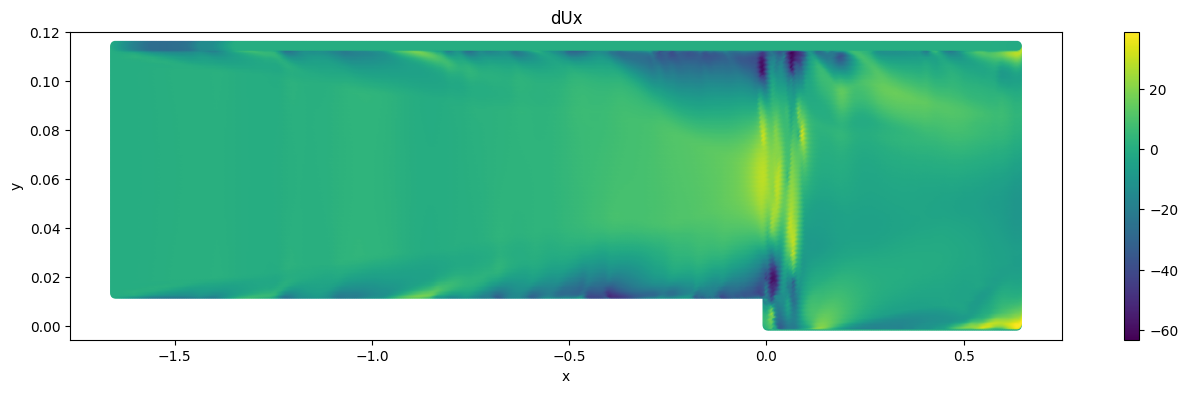

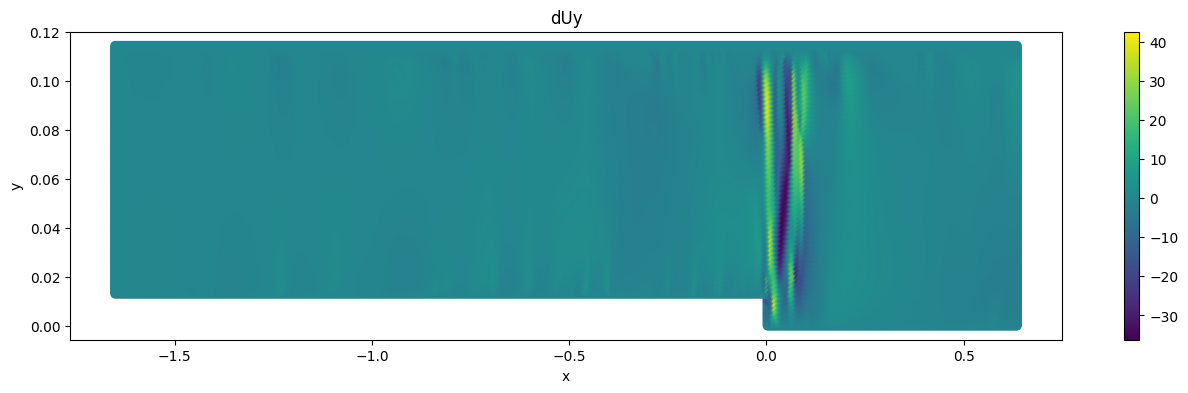

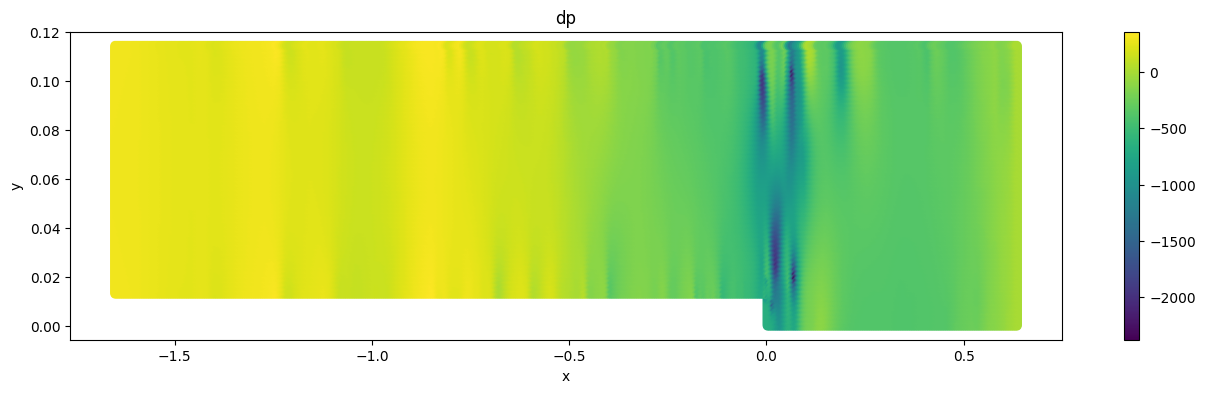

In [ ]:
plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["dUx"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("dUx")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["dUy"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("dUy")
plt.show()

plt.figure(figsize=(16, 4))
plt.scatter(df["x"], df["y"], c=df["dp"])
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("dp")
plt.show()

## Configuração de Dataset e Arquitetura

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32
print(f"Dispositivo: {DEVICE}")

FEAT_COLS = ["x", "y", "Ux", "Uy", "p", "k", "nut_log","Re"]

# ajuste aqui se seus targets têm outros nomes
TARGET_COLS = ["dUx", "dUy", "dp"]  # (ΔUx_true, ΔUy_true)

# -----------------------------
# 1) Dataset
# -----------------------------
class CFDParquet(Dataset):
    def __init__(self, df, feat_cols, target_cols=None, x_scaler=None, y_scaler=None):
        self.X = df[feat_cols].to_numpy(dtype=np.float32)
        self.has_y = target_cols is not None
        self.Y = df[target_cols].to_numpy(dtype=np.float32) if self.has_y else None

        # scaler só para features (z-score)
        if x_scaler is None:
            mu = self.X.mean(axis=0, keepdims=True)
            sd = self.X.std(axis=0, keepdims=True) + 1e-8
            self.x_mu = mu
            self.x_sd = sd
        else:
            self.x_mu, self.x_sd = x_scaler

        if y_scaler is None and self.has_y:
            y_mu = self.Y.mean(axis=0, keepdims=True)
            y_sd = self.Y.std(axis=0, keepdims=True) + 1e-8
            self.y_mu = y_mu
            self.y_sd = y_sd
            
        else:
            self.y_mu, self.y_sd = y_scaler
        
        # normaliza X e Y
        self.Xn = (self.X - self.x_mu) / self.x_sd
        self.Yn = (self.Y - self.y_mu) / self.y_sd

    def __len__(self):
        return self.Xn.shape[0]

    def __getitem__(self, idx):
        x = torch.tensor(self.Xn[idx], dtype=DTYPE)
        if self.has_y:
            y = torch.tensor(self.Yn[idx], dtype=DTYPE)
            return x, y
        return x


# -----------------------------
# 2) Arquitetura Geral MLP
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, width=128, depth=6, act=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, width), act()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), act()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)

        # init leve (ajuda tanh)
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


Dispositivo: cuda


## Funções auxiliares (Autodiff e Plots)

In [28]:
# -----------------------------
# 3) Autodiff util
# -----------------------------
def grad(outputs, inputs):
    # outputs: (N,1) or (N,)
    # inputs: (N,1)
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]

def laplacian(f, x, y):
    fx = grad(f, x)
    fy = grad(f, y)
    fxx = grad(fx, x)
    fyy = grad(fy, y)
    return fxx + fyy


# ----------------------------
# 4) Métricas
# ----------------------------
def mae_vec(u1, v1, u2, v2):
        return float(np.mean(np.sqrt((u1 - u2)**2 + (v1 - v2)**2)))
    
def mae_vec_pressure(p1, p2):
    return float(np.mean(np.abs(p1 - p2)))

def rmse_uv(u1, v1, u2, v2):
    return float(np.sqrt(np.mean((u1-u2)**2 + (v1-v2)**2)))

def rmse_p(p1, p2):
    return float(np.sqrt(np.mean((p1-p2)**2)))

def l2_relative_uv(u_pred, v_pred, u_ref, v_ref):
    num = np.sqrt(np.sum((u_pred - u_ref)**2 + (v_pred - v_ref)**2))
    den = np.sqrt(np.sum(u_ref**2 + v_ref**2))
    return float(num / (den + 1e-12))

def l2_relative_p(p_pred, p_ref):
    num = np.linalg.norm(p_pred - p_ref)
    den = np.linalg.norm(p_ref)
    return float(num / (den + 1e-12))


# ----------------------------
# 5) Plots
# ----------------------------
def plot_field_compare(
    df_plot,
    field_c,
    field_f,
    field_corr,
    title,
    h=0.0127,
    cmap="viridis"
):
    # Coordenadas adimensionais
    x = df_plot["x"].values / h
    y = df_plot["y"].values / h

    vals = np.concatenate([
        df_plot[field_c].values,
        df_plot[field_f].values,
        df_plot[field_corr].values
    ])

    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(22, 4),
        constrained_layout=True
    )

    titles = ["Coarse", "Fine", "Corrigido"]
    fields = [field_c, field_f, field_corr]

    for ax, f, t in zip(axes, fields, titles):

        sc = ax.scatter(
            x,
            y,
            c=df_plot[f].values,
            s=4,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(f"{title} — {t}")

        ax.set_xlabel(r"$x/h$")
        ax.set_ylabel(r"$y/h$")

        # Domínio do Driver & Seegmiller
        ax.set_xlim([-130, 50])
        ax.set_ylim([0, 9])

        # Não preservar a razão física extrema
        ax.set_aspect("auto")

    fig.colorbar(sc, ax=axes, label=title)

    plt.show()

# -------------------------------------------------
# 5.1. Mapas de erro: Coarse - Fine vs Corrigido - Fine
# -------------------------------------------------

def plot_error_compare(
    df_plot,
    field_c,
    field_f,
    field_corr,
    label,
    h=0.0127,
    save_path=None
):
    x = df_plot["x"].values / h
    y = df_plot["y"].values / h

    err_base = df_plot[field_c].values - df_plot[field_f].values
    err_corr = df_plot[field_corr].values - df_plot[field_f].values

    vmax = max(
        np.nanmax(np.abs(err_base)),
        np.nanmax(np.abs(err_corr))
    )
    vmin = -vmax

    fig, axes = plt.subplots(
        1, 2,
        figsize=(22, 6),
        constrained_layout=True
    )

    plots = [
        (axes[0], err_base, f"Erro {label}: Coarse - Fine"),
        (axes[1], err_corr, f"Erro {label}: Corrigido - Fine"),
    ]

    for ax, err, title in plots:
        sc = ax.scatter(
            x, y,
            c=err,
            s=4,
            cmap="coolwarm",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(title)
        ax.set_xlabel(r"$x/h$")
        ax.set_ylabel(r"$y/h$")
        ax.set_xlim([-130, 50])
        ax.set_ylim([0, 9])
        ax.set_aspect("auto")

    fig.colorbar(sc, ax=axes, label=f"Erro {label}")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


# -------------------------------------------------
# 5.2. Ganho local: |erro coarse| - |erro corrigido|
# -------------------------------------------------

def plot_local_gain(
    df_plot,
    field_c,
    field_f,
    field_corr,
    label,
    h=0.0127,
    save_path=None
):
    x = df_plot["x"].values / h
    y = df_plot["y"].values / h

    err_base = df_plot[field_c].values - df_plot[field_f].values
    err_corr = df_plot[field_corr].values - df_plot[field_f].values

    gain = np.abs(err_base) - np.abs(err_corr)

    vmax = np.nanmax(np.abs(gain))
    vmin = -vmax

    fig, ax = plt.subplots(figsize=(18, 6), constrained_layout=True)

    sc = ax.scatter(
        x, y,
        c=gain,
        s=4,
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"Ganho local — {label}")
    ax.set_xlabel(r"$x/h$")
    ax.set_ylabel(r"$y/h$")
    ax.set_xlim([-130, 50])
    ax.set_ylim([0, 9])
    ax.set_aspect("auto")

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f"|erro coarse| - |erro corrigido| ({label})")

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

def plot_error_histogram(
    df_plot,
    field_c,
    field_f,
    field_corr,
    label,
    bins=100,
    save_path=None
):
    err_coarse = np.abs(
        df_plot[field_c].values -
        df_plot[field_f].values
    )

    err_corr = np.abs(
        df_plot[field_corr].values -
        df_plot[field_f].values
    )

    fig, ax = plt.subplots(
        figsize=(8, 5),
        constrained_layout=True
    )

    ax.hist(
        err_coarse,
        bins=bins,
        alpha=0.6,
        density=True,
        label="Coarse",
        edgecolor="black"
    )

    ax.hist(
        err_corr,
        bins=bins,
        alpha=0.6,
        density=True,
        label="Corrigido",
        edgecolor="black"
    )

    ax.set_xlabel(f"|Erro| ({label})")
    ax.set_ylabel("Densidade")

    ax.set_title(
        f"Distribuição do erro absoluto - {label}"
    )

    ax.legend()
    ax.grid(True, alpha=0.3)

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()


def plot_scatter_prediction(
    df_plot,
    field_f,
    field_corr,
    label,
    sample_frac=1.0,
    save_path=None
):
    df_tmp = df_plot

    if sample_frac < 1.0:
        df_tmp = df_plot.sample(
            frac=sample_frac,
            random_state=42
        )

    x = df_tmp[field_f].values
    y = df_tmp[field_corr].values

    lim_min = min(x.min(), y.min())
    lim_max = max(x.max(), y.max())

    fig, ax = plt.subplots(
        figsize=(6, 6),
        constrained_layout=True
    )

    ax.scatter(
        x,
        y,
        s=3,
        alpha=0.3
    )

    ax.plot(
        [lim_min, lim_max],
        [lim_min, lim_max],
        'r--',
        linewidth=2,
        label="y=x"
    )

    ax.set_xlabel(f"{label} Fine")
    ax.set_ylabel(f"{label} Corrigido")

    ax.set_title(
        f"{label}: Predito vs Referência"
    )

    ax.legend()
    ax.grid(True, alpha=0.3)

    ax.set_aspect("equal")

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

## Funções utilitárias de treino e métricas

In [29]:
# Treino em batch supervisionado
def train_supervised_epoch(net, dl_data, opt, device):
    net.train()
    
    total_loss = 0.0
    n_train = 0

    for batch in dl_data:
        Xn, Yn = batch
        Xn = Xn.to(device)
        Yn = Yn.to(device)

        # =========================
        # (Loss de dados (ΔU)
        # =========================
        pred_data = net(Xn)  # forward normal
        loss = torch.mean((pred_data - Yn) ** 2)   # pred_data é (N,3) e Yn é (N,3)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item() * Xn.size(0)
        n_train += Xn.size(0)
    return total_loss / n_train

# Avaliação da loss com dados de teste
def validate_supervised(net, dl_val, device):
    net.eval()
    val_total = 0.0
    n_val = 0
    with torch.no_grad():
        for Xv, Yv in dl_val:
            Xv = Xv.to(device)
            Yv = Yv.to(device)

            pred_v = net(Xv)
            loss_v = torch.mean((pred_v - Yv) ** 2)

            val_total += loss_v.item() * Xv.size(0)
            n_val += Xv.size(0)

    return val_total / n_val

# Update do modelo com melhor loss
def update_best_model(net, loss_val, best_val, bad, model_path):
    improved = loss_val < best_val
    if improved:
            best_val = loss_val
            bad = 0
            torch.save(net.state_dict(), model_path )
    else:
        bad += 1

    return best_val, bad, improved


# -------------------------------
# Função de Avaliação / Métricas
# -------------------------------
@torch.no_grad()
def evaluate_metrics(
    model, parquet_test_path, feat_cols, xscaler, yscaler,
    batch_size=4900, model_metrics = None,
    out_metrics= PATH_METRIC / "metrics_metrics.json"
):

    model.eval()
    device = next(model.parameters()).device

    df = pd.read_parquet(parquet_test_path)

    Ux_c = df["Ux"].to_numpy(np.float32)
    Uy_c = df["Uy"].to_numpy(np.float32)
    p_c  = df["p"].to_numpy(np.float32)

    dUx_true = df["dUx"].to_numpy(np.float32)
    dUy_true = df["dUy"].to_numpy(np.float32)
    dp_true  = df["dp"].to_numpy(np.float32)

    Ux_f = Ux_c + dUx_true
    Uy_f = Uy_c + dUy_true
    p_f  = p_c  + dp_true

    X = df[feat_cols].to_numpy(np.float32)
    x_mu, x_sd = xscaler
    y_mu, y_sd = yscaler
    Xn = (X - x_mu) / x_sd

    dUx_pred = np.zeros(len(df), dtype=np.float32)
    dUy_pred = np.zeros(len(df), dtype=np.float32)
    dp_pred = np.zeros(len(df), dtype=np.float32)
    
    for i0 in range(0, len(df), batch_size):
        i1 = min(i0 + batch_size, len(df))
        xb = torch.tensor(Xn[i0:i1], dtype=torch.float32, device=device)
        out_n = model(xb)[:, :3].detach().cpu().numpy()
        out = out_n * y_sd + y_mu
        dUx_pred[i0:i1] = out[:, 0]
        dUy_pred[i0:i1] = out[:, 1]
        dp_pred[i0:i1] = out[:, 2]

    Ux_hat = Ux_c + dUx_pred
    Uy_hat = Uy_c + dUy_pred
    p_hat = p_c + dp_pred

    # Plotagem comparativa dos perfis de velocidade e pressão
    pred_df = df[["x", "y", "Ux", "Uy", "p", "dUx", "dUy", "dp"]].copy()

    pred_df["Ux_f"] = pred_df["Ux"] + pred_df["dUx"]
    pred_df["Uy_f"] = pred_df["Uy"] + pred_df["dUy"]
    pred_df["p_f"]  = pred_df["p"]  + pred_df["dp"]

    pred_df["dUx_pred"] = dUx_pred
    pred_df["dUy_pred"] = dUy_pred
    pred_df["dp_pred"]  = dp_pred

    pred_df["Ux_corr"] = pred_df["Ux"] + pred_df["dUx_pred"]
    pred_df["Uy_corr"] = pred_df["Uy"] + pred_df["dUy_pred"]
    pred_df["p_corr"]  = pred_df["p"]  + pred_df["dp_pred"]
    
    #MAE
    mae_coarse = mae_vec(Ux_c, Uy_c, Ux_f, Uy_f)
    mae_p_coarse = mae_vec_pressure(p_c, p_f)
    mae_corr   = mae_vec(Ux_hat, Uy_hat, Ux_f, Uy_f)
    mae_p_corr = mae_vec_pressure(p_hat, p_f)
    mae_deltas = mae_vec(dUx_pred, dUy_pred, dUx_true, dUy_true)
    mae_deltas_p = mae_vec_pressure(dp_pred, dp_true)

    #RMSE
    rmse_uv_coarse = rmse_uv(Ux_c, Uy_c, Ux_f, Uy_f)
    rmse_uv_corr = rmse_uv(Ux_hat, Uy_hat, Ux_f, Uy_f)
    rmse_p_coarse = rmse_p(p_c, p_f)
    rmse_p_corr = rmse_p(p_hat, p_f)

    #RER
    rer_uv = 1.0 - (mae_corr / (mae_coarse + 1e-12))
    melhora_pct_uv = rer_uv * 100.0
    rer_p = 1.0 - (mae_p_corr / (mae_p_coarse + 1e-12))
    melhora_pct_p = rer_p * 100.0

    #L2
    l2_coarse_uv = l2_relative_uv(Ux_c, Uy_c, Ux_f, Uy_f)
    l2_corr_uv   = l2_relative_uv(Ux_hat, Uy_hat, Ux_f, Uy_f)
    l2_coarse_p = l2_relative_p(p_c, p_f)
    l2_corr_p   = l2_relative_p(p_hat, p_f)

    # -------------------------------------------------
    # Métricas de dados e física
    # -------------------------------------------------

    metrics = {
        "mae_uv_coarse_to_fine": mae_coarse,
        "mae_uv_corrected_to_fine": mae_corr,
        "mae_uv_deltas_pred_vs_true": mae_deltas,
        "mae_p_pressure_coarse_to_fine": mae_p_coarse,
        "mae_p_corrected_to_fine": mae_p_corr,
        "mae_p_deltas_pred_vs_true": mae_deltas_p,
        "rmse_uv_coarse_to_fine": rmse_uv_coarse,
        "rmse_uv_corrected_to_fine": rmse_uv_corr,
        "rmse_p_coarse_to_fine": rmse_p_coarse,
        "rmse_p_corrected_to_fine": rmse_p_corr,
        "l2_rel_uv_coarse": l2_coarse_uv,
        "l2_rel_uv_corrected": l2_corr_uv,
        "l2_rel_p_coarse": l2_coarse_p,
        "l2_rel_p_corrected": l2_corr_p,
        "RER (u,v)": float(rer_uv),
        "RER (p)": float(rer_p),
        "melhora_MAE_pct": float(melhora_pct_uv),
        "melhora_MAE_pct_pressure": float(melhora_pct_p),
        "N": int(len(df)),
    }

    with open(out_metrics, "w") as f:
        json.dump(metrics, f, indent=2)

    print(f"\n===== Métricas ({model_metrics}) =====")
    print(f"MAE vetorial (u,v) (coarse -> fine):      {mae_coarse:.6f}")
    print(f"MAE pressão (p) (coarse -> fine):         {mae_p_coarse:.6f}")
    print(f"MAE vetorial (u,v) (corrigido -> fine):   {mae_corr:.6f}")
    print(f"MAE pressão (p) (corrigido -> fine):      {mae_p_corr:.6f}")
    print(f"MAE vetorial (ΔU_pred -> ΔU_true):        {mae_deltas:.6f}")
    print(f"MAE pressão (Δp_pred -> Δp_true):         {mae_deltas_p:.6f}")
    print(f"RMSE (u,v) (coarse -> fine):              {rmse_uv_coarse:.6f}")
    print(f"RMSE (u,v) (corrigido -> fine):           {rmse_uv_corr:.6f}")
    print(f"RMSE (p)   (coarse -> fine):              {rmse_p_coarse:.6f}")
    print(f"RMSE (p)   (corrigido -> fine):           {rmse_p_corr:.6f}")
    print(f"RER (u,v):                                {rer_uv:.4f}")
    print(f"RER (p):                                  {rer_p:.4f}")
    print(f"Melhora (u,v) (MAE):                      {melhora_pct_uv:.2f}%")
    print(f"Melhora (p) (MAE):                        {melhora_pct_p:.2f}%")

    print(f"\n===== Métricas Físicas ({model_metrics}) =====")
    print(f"L2 relativo (u,v) - Coarse:               {l2_coarse_uv:.6e}")
    print(f"L2 relativo (u,v) - Corrigido:            {l2_corr_uv:.6e}")
    print(f"L2 relativo (p) - Coarse:                 {l2_coarse_p:.6e}")
    print(f"L2 relativo (p) - Corrigido:              {l2_corr_p:.6e}")
    print(f"Salvo: {out_metrics}\n")

    return metrics

## Treino MLP Supervisionada - Baseline

In [37]:
# -----------------------------------
# Função de Treino MLP Supervisionada
# -----------------------------------
def train_mlp(
    parquet_path,
    feat_cols,
    target_cols,
    batch_data=4096,
    epochs=50,
    width=64,
    depth=4,
    lr=1e-3,
    lr_wd=1e-6, 
    predict_dp=True,
    out_model="model",
    seed=42
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    df = pd.read_parquet(parquet_path)

    # Split simples (pode trocar por split espacial/estratificado por região de wz)
    n = len(df)
    idx = np.random.permutation(n)
    ntr = int(0.8 * n)
    tr_idx, te_idx = idx[:ntr], idx[ntr:]

    df_tr = df.iloc[tr_idx].reset_index(drop=True)
    df_te = df.iloc[te_idx].reset_index(drop=True)

    # Dataset supervisionado (dados treino)
    train_ds = CFDParquet(df_tr, feat_cols, target_cols)
    dl_data = DataLoader(train_ds, batch_size=batch_data, shuffle=True, drop_last=True)

    # Dataset supervisionado (dados de avaliação)
    # Salvar dataset de teste
    out_test = f"dataset_test_mlp_{out_model}_d{depth}_w{width}.parquet"
    df_te.to_parquet(PATH_DATA / out_test, index=False)
    print(f"Salvo dataset TESTE: {out_test}")

    test_ds = CFDParquet(df_te, feat_cols, target_cols, 
                         x_scaler=(train_ds.x_mu, train_ds.x_sd), 
                         y_scaler=(train_ds.y_mu, train_ds.y_sd))
    dl_val = DataLoader(test_ds, batch_size=batch_data, shuffle=False, drop_last=False)

    in_dim = len(feat_cols)
    out_dim = 3 if predict_dp else 2
    net = MLP(in_dim=in_dim, out_dim=out_dim, width=width, depth=depth, act=nn.Tanh).to(DEVICE)

    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=lr_wd)

    # treino + early stopping na VAL
    best_val = float("inf")
    bad = 0

    patience_es = 20
    patience_lr = 10
    
    # implementa o scheduler para ajustar o learning rate automaticamente
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        factor=0.5,
        patience=patience_lr
    )
    model_name = f"mlp_{out_model}_d{depth}_w{width}.pt"

    # ---- Treino supervisionado (dados)
    for ep in range(1, epochs + 1):
        
        loss_train = train_supervised_epoch(net, dl_data, opt, DEVICE)

        # Faz a avaliação no dataset de teste
        loss_val = validate_supervised(net, dl_val, DEVICE)
        scheduler.step(loss_val)

        best_val, bad, improved = update_best_model(net, loss_val, best_val, bad, PATH_MODEL / model_name)
        
        if bad >= patience_es:
            print(f"Early stopping (val não melhorou). Melhor loss_val: {best_val}")
            break

        if ep % 10 == 0 or ep == 1:
            print(
                f"[MLP] ep={ep:03d} "
                f"loss_train={loss_train:.6e} | "
                f"loss_val={loss_val:.6e} | "
                f"lr={opt.param_groups[0]['lr']:.2e}"
            )
    # Recupera e retorna o modelo com melhor loss
    net.load_state_dict(torch.load(PATH_MODEL / model_name, map_location=DEVICE))
    return net, (train_ds.x_mu, train_ds.x_sd), (train_ds.y_mu, train_ds.y_sd)

### Execução do Treino

In [ ]:
# ---------------------------------
# Treinar a MLP e avaliar
# ---------------------------------
model, xscaler, yscaler= train_mlp(
    parquet_path=PATH_DATA / "dataset_bfs_2d_kepsilon_with_wz.parquet",
    feat_cols=FEAT_COLS,
    target_cols=TARGET_COLS,
    epochs=1000,
    lr=1e-3,
    lr_wd=1e-6,
    predict_dp=True,
    out_model = "k_epsilon"
)

# salvar modelo e scalers
joblib.dump(xscaler, PATH_MODEL / "mlp_scaler_X.pkl")
joblib.dump(yscaler, PATH_MODEL / "mlp_scaler_Y.pkl")
print("Salvo scalers da MLP!")

# Avaliação no dataset de TESTE
print("###############################################################")
print("################### Avaliação Dataset Teste ###################")
print("###############################################################")
evaluate_metrics(
    model=model,
    parquet_test_path=PATH_DATA / "dataset_test_pinn_with_wz.parquet",
    feat_cols=FEAT_COLS,
    xscaler=xscaler,
    yscaler=yscaler,
    model_metrics = "MLP",
    out_metrics=PATH_METRIC / "metrics_test_mlp_with_wz.json"
)

# Avaliação no dataset COMPLETO
print("##################################################################")
print("################### Avaliação Dataset Completo ###################")
print("##################################################################")
evaluate_metrics(
    model=model,
    parquet_test_path=PATH_DATA / "dataset_bfs_2d_kepsilon_with_wz.parquet",
    feat_cols=FEAT_COLS,
    xscaler=xscaler,
    yscaler=yscaler,
    model_metrics = "MLP",
    out_metrics=PATH_METRIC / "metrics_full_mlp_with_wz.json"
)


Salvo dataset TESTE: dataset_test_mlp_k_epsilon_d4_w64.parquet
[MLP] ep=001 loss_train=7.548997e-01 | loss_val=6.410879e-01 | lr=1.00e-03
[MLP] ep=010 loss_train=4.417362e-01 | loss_val=4.067867e-01 | lr=1.00e-03
[MLP] ep=020 loss_train=3.187910e-01 | loss_val=2.872720e-01 | lr=1.00e-03
[MLP] ep=030 loss_train=2.402703e-01 | loss_val=2.212320e-01 | lr=1.00e-03
[MLP] ep=040 loss_train=1.948665e-01 | loss_val=1.783265e-01 | lr=1.00e-03
[MLP] ep=050 loss_train=1.696144e-01 | loss_val=1.622232e-01 | lr=1.00e-03
[MLP] ep=060 loss_train=1.462192e-01 | loss_val=1.411790e-01 | lr=1.00e-03
[MLP] ep=070 loss_train=1.318873e-01 | loss_val=1.282800e-01 | lr=1.00e-03
[MLP] ep=080 loss_train=1.221990e-01 | loss_val=1.179612e-01 | lr=1.00e-03
[MLP] ep=090 loss_train=1.095816e-01 | loss_val=1.092195e-01 | lr=1.00e-03
[MLP] ep=100 loss_train=9.982967e-02 | loss_val=1.003358e-01 | lr=1.00e-03
[MLP] ep=110 loss_train=9.102359e-02 | loss_val=9.299994e-02 | lr=1.00e-03
[MLP] ep=120 loss_train=8.254478e-02 

{'mae_uv_coarse_to_fine': 6.021580696105957,
 'mae_uv_corrected_to_fine': 0.7418793439865112,
 'mae_uv_deltas_pred_vs_true': 0.7418793439865112,
 'mae_p_pressure_coarse_to_fine': 284.13525390625,
 'mae_p_corrected_to_fine': 18.39498519897461,
 'mae_p_deltas_pred_vs_true': 18.394987106323242,
 'rmse_uv_coarse_to_fine': 9.71419620513916,
 'rmse_uv_corrected_to_fine': 1.3525824546813965,
 'rmse_p_coarse_to_fine': 345.0668640136719,
 'rmse_p_corrected_to_fine': 28.68501091003418,
 'l2_rel_uv_coarse': 0.21607980132102966,
 'l2_rel_uv_corrected': 0.03008645959198475,
 'l2_rel_p_coarse': 0.8669746518135071,
 'l2_rel_p_corrected': 0.07207059860229492,
 'RER (u,v)': 0.8767965786016706,
 'RER (p)': 0.9352597576468145,
 'melhora_MAE_pct': 87.67965786016705,
 'melhora_MAE_pct_pressure': 93.52597576468145,
 'N': 100975}

## Plots e avaliação

In [26]:
def plots_evaluate_model(
    model, parquet_test_path, feat_cols, xscaler, yscaler,
    batch_size=4900, out_name=None
    ):

    model.eval()
    device = next(model.parameters()).device

    df = pd.read_parquet(parquet_test_path)

    X = df[feat_cols].to_numpy(np.float32)
    x_mu, x_sd = xscaler
    y_mu, y_sd = yscaler
    Xn = (X - x_mu) / x_sd

    dUx_pred = np.zeros(len(df), dtype=np.float32)
    dUy_pred = np.zeros(len(df), dtype=np.float32)
    dp_pred = np.zeros(len(df), dtype=np.float32)
    
    for i0 in range(0, len(df), batch_size):
        i1 = min(i0 + batch_size, len(df))
        xb = torch.tensor(Xn[i0:i1], dtype=torch.float32, device=device)
        out_n = model(xb)[:, :3].detach().cpu().numpy()
        out = out_n * y_sd + y_mu
        dUx_pred[i0:i1] = out[:, 0]
        dUy_pred[i0:i1] = out[:, 1]
        dp_pred[i0:i1] = out[:, 2]

    # Plotagem comparativa dos perfis de velocidade e pressão
    pred_df = df[["x", "y", "Ux", "Uy", "p", "dUx", "dUy", "dp"]].copy()

    pred_df["Ux_f"] = pred_df["Ux"] + pred_df["dUx"]
    pred_df["Uy_f"] = pred_df["Uy"] + pred_df["dUy"]
    pred_df["p_f"]  = pred_df["p"]  + pred_df["dp"]

    pred_df["dUx_pred"] = dUx_pred
    pred_df["dUy_pred"] = dUy_pred
    pred_df["dp_pred"]  = dp_pred

    pred_df["Ux_corr"] = pred_df["Ux"] + pred_df["dUx_pred"]
    pred_df["Uy_corr"] = pred_df["Uy"] + pred_df["dUy_pred"]
    pred_df["p_corr"]  = pred_df["p"]  + pred_df["dp_pred"]


    # -------------------------------------------------
    # Executar Plots para Ux, Uy e p
    # -------------------------------------------------
    
    # Comparativo de compos para Ux, Uy e p
    plot_field_compare(pred_df, "Ux", "Ux_f", "Ux_corr", "Ux")
    plot_field_compare(pred_df, "Uy", "Uy_f", "Uy_corr", "Uy")
    plot_field_compare(pred_df, "p", "p_f", "p_corr", "p")

    # Comparativo de erro para Ux, Uy e p
    plot_error_compare(
        pred_df,
        field_c="Ux",
        field_f="Ux_f",
        field_corr="Ux_corr",
        label="Ux",
        save_path=PATH_PLOT / f"erro_Ux_coarse_vs_corrigido_{out_name}.png"
    )

    plot_error_compare(
        pred_df,
        field_c="Uy",
        field_f="Uy_f",
        field_corr="Uy_corr",
        label="Uy",
        save_path=PATH_PLOT / f"erro_Uy_coarse_vs_corrigido_{out_name}.png"
    )

    plot_error_compare(
        pred_df,
        field_c="p",
        field_f="p_f",
        field_corr="p_corr",
        label="p",
        save_path=PATH_PLOT / f"erro_p_coarse_vs_corrigido_{out_name}.png"
    )

    # Comparativo de ganho local para Ux, Uy e p
    plot_local_gain(
        pred_df,
        field_c="Ux",
        field_f="Ux_f",
        field_corr="Ux_corr",
        label="Ux",
        save_path=PATH_PLOT / f"ganho_local_Ux_{out_name}.png"
    )

    plot_local_gain(
        pred_df,
        field_c="Uy",
        field_f="Uy_f",
        field_corr="Uy_corr",
        label="Uy",
        save_path=PATH_PLOT / f"ganho_local_Uy__{out_name}.png"
    )

    plot_local_gain(
        pred_df,
        field_c="p",
        field_f="p_f",
        field_corr="p_corr",
        label="p",
        save_path=PATH_PLOT / f"ganho_local_p__{out_name}.png"
    )

# Executa os plots
model_name = "mlp_k_epsilon_d4_w64.pt"

model = MLP(
    in_dim=len(FEAT_COLS),
    out_dim=3,
    width=64,
    depth=4,
    act=nn.Tanh
).to(DEVICE)

model.load_state_dict(torch.load(PATH_MODEL / model_name, map_location=DEVICE))

plots_evaluate_model(
    model=model,
    parquet_test_path=PATH_DATA / "dataset_bfs_2d_kepsilon.parquet",
    feat_cols=FEAT_COLS,
    xscaler=xscaler,
    yscaler=yscaler,
    out_name= "mlp_with_wz"
)

NameError: name 'xscaler' is not defined

A correção aprendida pela MLP reduz significativamente o erro coarse→fine, preservando a maior parte do domínio com erro residual baixo. As maiores discrepâncias remanescentes concentram-se na região de separação e reatacamento, onde os gradientes do escoamento são mais intensos.

In [ ]:
def plots_evaluate_model(
    model, parquet_test_path, feat_cols, xscaler, yscaler,
    batch_size=4900, out_name=None
    ):

    model.eval()
    device = next(model.parameters()).device

    df = pd.read_parquet(parquet_test_path)

    X = df[feat_cols].to_numpy(np.float32)
    x_mu, x_sd = xscaler
    y_mu, y_sd = yscaler
    Xn = (X - x_mu) / x_sd

    dUx_pred = np.zeros(len(df), dtype=np.float32)
    dUy_pred = np.zeros(len(df), dtype=np.float32)
    dp_pred = np.zeros(len(df), dtype=np.float32)
    
    for i0 in range(0, len(df), batch_size):
        i1 = min(i0 + batch_size, len(df))
        xb = torch.tensor(Xn[i0:i1], dtype=torch.float32, device=device)
        out_n = model(xb)[:, :3].detach().cpu().numpy()
        out = out_n * y_sd + y_mu
        dUx_pred[i0:i1] = out[:, 0]
        dUy_pred[i0:i1] = out[:, 1]
        dp_pred[i0:i1] = out[:, 2]

    # Plotagem comparativa dos perfis de velocidade e pressão
    pred_df = df[["x", "y", "Ux", "Uy", "p", "dUx", "dUy", "dp"]].copy()

    pred_df["Ux_f"] = pred_df["Ux"] + pred_df["dUx"]
    pred_df["Uy_f"] = pred_df["Uy"] + pred_df["dUy"]
    pred_df["p_f"]  = pred_df["p"]  + pred_df["dp"]

    pred_df["dUx_pred"] = dUx_pred
    pred_df["dUy_pred"] = dUy_pred
    pred_df["dp_pred"]  = dp_pred

    pred_df["Ux_corr"] = pred_df["Ux"] + pred_df["dUx_pred"]
    pred_df["Uy_corr"] = pred_df["Uy"] + pred_df["dUy_pred"]
    pred_df["p_corr"]  = pred_df["p"]  + pred_df["dp_pred"]


    # -------------------------------------------------
    # Executar Plots para Ux, Uy e p
    # -------------------------------------------------
    
    # Comparativo de compos para Ux, Uy e p
    plot_field_compare(pred_df, "Ux", "Ux_f", "Ux_corr", "Ux")
    plot_field_compare(pred_df, "Uy", "Uy_f", "Uy_corr", "Uy")
    plot_field_compare(pred_df, "p", "p_f", "p_corr", "p")

    # Comparativo de erro para Ux, Uy e p
    plot_error_compare(
        pred_df,
        field_c="Ux",
        field_f="Ux_f",
        field_corr="Ux_corr",
        label="Ux",
        save_path=PATH_PLOT / f"erro_Ux_coarse_vs_corrigido_{out_name}.png"
    )

    plot_error_compare(
        pred_df,
        field_c="Uy",
        field_f="Uy_f",
        field_corr="Uy_corr",
        label="Uy",
        save_path=PATH_PLOT / f"erro_Uy_coarse_vs_corrigido_{out_name}.png"
    )

    plot_error_compare(
        pred_df,
        field_c="p",
        field_f="p_f",
        field_corr="p_corr",
        label="p",
        save_path=PATH_PLOT / f"erro_p_coarse_vs_corrigido_{out_name}.png"
    )

    # Comparativo de ganho local para Ux, Uy e p
    plot_local_gain(
        pred_df,
        field_c="Ux",
        field_f="Ux_f",
        field_corr="Ux_corr",
        label="Ux",
        save_path=PATH_PLOT / f"ganho_local_Ux_{out_name}.png"
    )

    plot_local_gain(
        pred_df,
        field_c="Uy",
        field_f="Uy_f",
        field_corr="Uy_corr",
        label="Uy",
        save_path=PATH_PLOT / f"ganho_local_Uy__{out_name}.png"
    )

    plot_local_gain(
        pred_df,
        field_c="p",
        field_f="p_f",
        field_corr="p_corr",
        label="p",
        save_path=PATH_PLOT / f"ganho_local_p__{out_name}.png"
    )

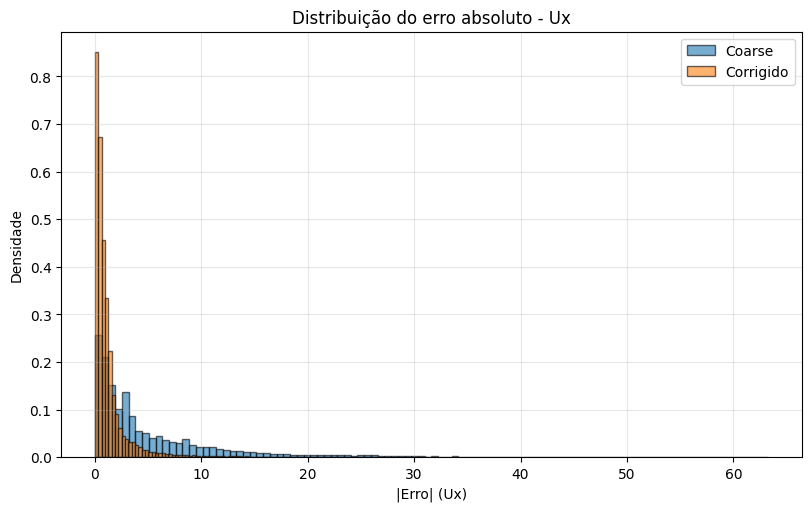

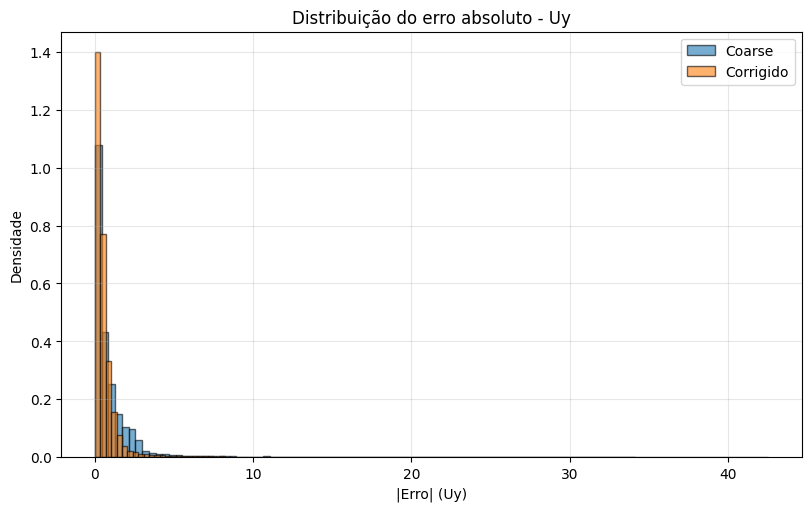

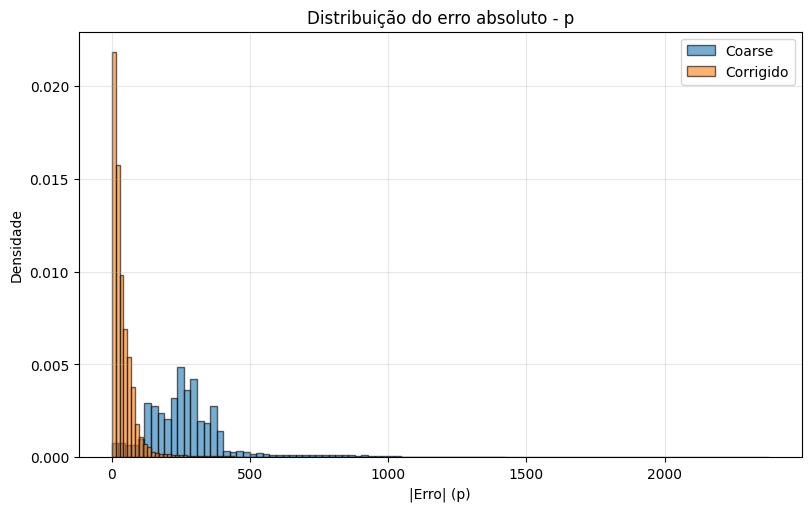

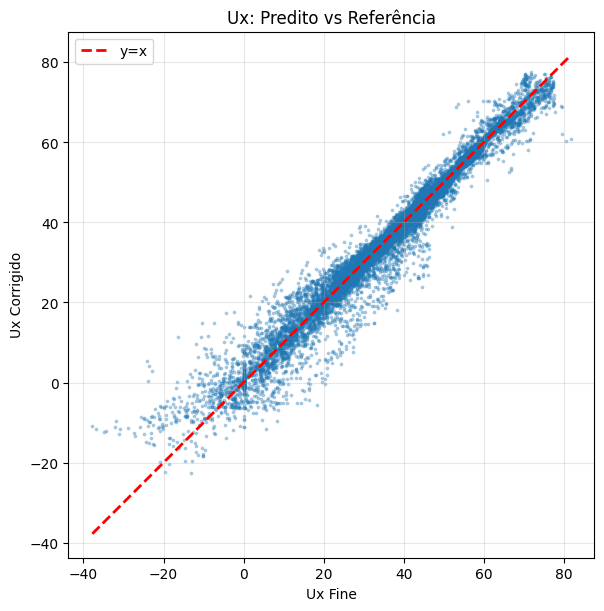

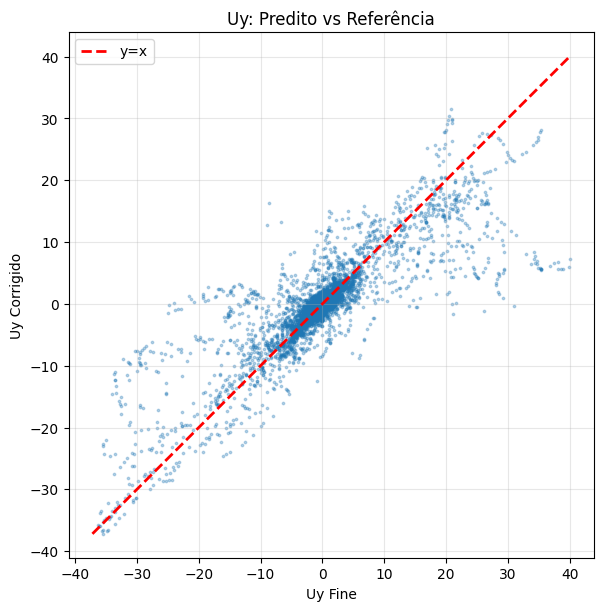

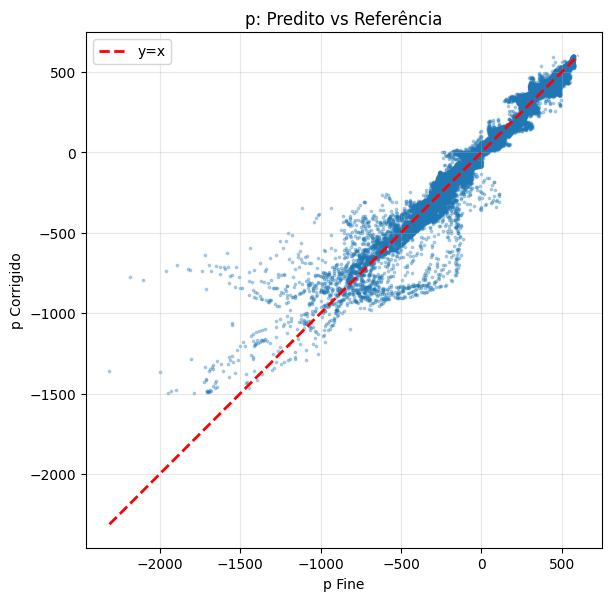

In [14]:
plot_error_histogram(
    pred_all,
    "Ux",
    "Ux_f",
    "Ux_corr",
    "Ux",
    save_path=PATH_OUT / "hist_error_Ux.png"
)

plot_error_histogram(
    pred_all,
    "Uy",
    "Uy_f",
    "Uy_corr",
    "Uy",
    save_path=PATH_OUT / "hist_error_Uy.png"
)

plot_error_histogram(
    pred_all,
    "p",
    "p_f",
    "p_corr",
    "p",
    save_path=PATH_OUT / "hist_error_p.png"
)

plot_scatter_prediction(
    pred_all,
    "Ux_f",
    "Ux_corr",
    "Ux",
    sample_frac=0.3,
    save_path=PATH_OUT / "scatter_Ux.png"
)

plot_scatter_prediction(
    pred_all,
    "Uy_f",
    "Uy_corr",
    "Uy",
    sample_frac=0.3,
    save_path=PATH_OUT / "scatter_Uy.png"
)

plot_scatter_prediction(
    pred_all,
    "p_f",
    "p_corr",
    "p",
    sample_frac=0.3,
    save_path=PATH_OUT / "scatter_p.png"
)

As distribuições de erro absoluto apresentaram forte concentração em torno de zero após a correção via MLP, acompanhada pela redução das caudas de alta magnitude. Isso indica que o modelo não apenas reduz erros pontuais, mas melhora sistematicamente a solução em praticamente todo o domínio computacional.

In [15]:
from sklearn.metrics import r2_score

print("R2 Ux :", r2_score(pred_all["Ux_f"], pred_all["Ux_corr"]))
print("R2 Uy :", r2_score(pred_all["Uy_f"], pred_all["Uy_corr"]))
print("R2 p  :", r2_score(pred_all["p_f"], pred_all["p_corr"]))

R2 Ux : 0.9678207130276193
R2 Uy : 0.7161777365543924
R2 p  : 0.9587433215497334


# Treino PINN híbrida

## V1 — PINN só com continuidade

## Funções utilitárias PINN

In [38]:
# ---------------------------------------------------------------------------------
# Definindo os Resíduos físicos (2D incompressível, estacionário) - Só continuidade
# ---------------------------------------------------------------------------------
def pde_residuals_continuity(x, y, u_coarse, v_coarse, model_out):
    """
    x, y: (N,1) leaf tensors com requires_grad=True (os mesmos do forward)
    model_out:
      se predict_dp=True: (N,3) = [dU, dV, dP]
      senão: (N,2) = [dU, dV]
    """

    dU, dV = model_out[:, [0]], model_out[:, [1]]

    u_hat = u_coarse + dU
    v_hat = v_coarse + dV

    # derivadas
    u_x = grad(u_hat, x)
    v_y = grad(v_hat, y)

    r_cont = u_x + v_y

    return r_cont

 # helper: pegar colunas específicas do batch (já normalizado) e voltar pra escala original
def unnormalize_x(Xn, x_sd, x_mu):
    return Xn * x_sd + x_mu

def unnormalize_y(Yn, y_sd, y_mu):
    return Yn* y_sd + y_mu

def train_pinn_epoch_continuity(
    net,
    dl_data,
    opt,
    feat_index,
    x_mu,
    x_sd,
    y_mu,
    y_sd,
    w_data,
    w_cont,
    device
):
    net.train()

    total_loss = 0.0
    total_data = 0.0
    total_cont = 0.0
    n_train = 0

    for Xn, Yn in dl_data:
        Xn = Xn.to(device)
        Yn = Yn.to(device)

        # Loss supervisionada em escala normalizada
        pred_data = net(Xn)
        loss_data = torch.mean((pred_data - Yn) ** 2)

        # Recupera X físico
        X_phys = unnormalize_x(Xn, x_sd, x_mu).detach()

        # x,y com gradiente para autograd
        x = X_phys[:, [feat_index["x"]]].clone().requires_grad_(True)
        y = X_phys[:, [feat_index["y"]]].clone().requires_grad_(True)

        # Reinjeta x,y no input físico
        X_phys_mod = X_phys.clone()
        X_phys_mod[:, [feat_index["x"]]] = x
        X_phys_mod[:, [feat_index["y"]]] = y

        # Renormaliza input
        Xn_mod = (X_phys_mod - x_mu) / x_sd

        # Predição normalizada e desnormalizada
        pred_phys_n = net(Xn_mod)
        pred_phys = pred_phys_n * y_sd + y_mu

        # Campos coarse físicos
        u_c = X_phys[:, [feat_index["Ux"]]]
        v_c = X_phys[:, [feat_index["Uy"]]]

        r_cont = pde_residuals_continuity(
            x=x,
            y=y,
            u_coarse=u_c,
            v_coarse=v_c,
            model_out=pred_phys
        )

        loss_cont = torch.mean(r_cont ** 2)

        loss = w_data * loss_data + w_cont * loss_cont

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        bs = Xn.size(0)
        total_loss += loss.item() * bs
        total_data += loss_data.item() * bs
        total_cont += loss_cont.item() * bs
        n_train += bs

    return (total_loss / n_train, 
            total_data / n_train, 
            total_cont / n_train
    )

In [ ]:
# -----------------------------
# Função de Treino
# -----------------------------
def train_pinn(
    parquet_path,
    feat_cols,
    target_cols,
    batch_data=4096,
    batch_phys=4096,
    epochs_pre=50,
    epochs_phys=100,
    width=64,
    depth=4,
    lr=1e-3,
    lr_wd=1e-6,
    w_data=1.0,
    w_cont=1.0,
    predict_dp=True,
    out_model="model",
    seed=42
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    df = pd.read_parquet(parquet_path)

    # Split simples (pode trocar por split espacial/estratificado por região de wz)
    n = len(df)
    idx = np.random.permutation(n)
    ntr = int(0.8 * n)
    tr_idx, te_idx = idx[:ntr], idx[ntr:]

    df_tr = df.iloc[tr_idx].reset_index(drop=True)
    df_te = df.iloc[te_idx].reset_index(drop=True)

    # Dataset supervisionado (dados)
    train_ds = CFDParquet(df_tr, feat_cols, target_cols)
    dl_data = DataLoader(train_ds, batch_size=batch_data, shuffle=True, drop_last=True)

    # Dataset supervisionado (dados de avaliação)
    # Salvar dataset de teste
    out_test = f"dataset_test_pinn_{out_model}_d{depth}_w{width}.parquet"
    df_te.to_parquet(PATH_DATA / out_test, index=False)
    print(f"Salvo dataset TESTE: {out_test}")

    test_ds = CFDParquet(df_te, feat_cols, target_cols, 
                         x_scaler=(train_ds.x_mu, train_ds.x_sd), 
                         y_scaler=(train_ds.y_mu, train_ds.y_sd))
    dl_val = DataLoader(test_ds, batch_size=batch_data, shuffle=False, drop_last=False)

    in_dim = len(feat_cols)
    out_dim = 3 if predict_dp else 2
    net = MLP(in_dim=in_dim, out_dim=out_dim, width=width, depth=depth, act=nn.Tanh).to(DEVICE)

    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=lr_wd)

     # treino + early stopping na VAL
    best_val = float("inf")
    bad = 0

    patience_es = 20
    patience_lr = 10
    
    # implementa o scheduler para ajustar o learning rate automaticamente
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        factor=0.5,
        patience=patience_lr
    )
    model_name = f"PINN_{out_model}_d{depth}_w{width}.pt"

    # helper: pegar colunas específicas do batch (já normalizado) e voltar pra escala original
    # aqui a gente precisa de x,y,Ux,Uy,p,Re em escala original pra PDE.
    feat_index = {c: i for i, c in enumerate(feat_cols)}

    x_mu = torch.as_tensor(train_ds.x_mu, dtype=DTYPE, device=DEVICE)
    x_sd = torch.as_tensor(train_ds.x_sd, dtype=DTYPE, device=DEVICE)
    y_mu = torch.as_tensor(train_ds.y_mu, dtype=DTYPE, device=DEVICE)
    y_sd = torch.as_tensor(train_ds.y_sd, dtype=DTYPE, device=DEVICE)


    # ---- STAGE 1: pré-treino supervisionado (dados)
    for ep in range(1, epochs_pre + 1):
        loss_pre = train_supervised_epoch(net, dl_data, opt, DEVICE)

            # Faz a avaliação no dataset de teste
        loss_val_pre = validate_supervised(net, dl_val, DEVICE)
        scheduler.step(loss_val_pre)

        best_val, bad, improved = update_best_model(net, loss_val_pre, best_val, bad, PATH_MODEL / model_name)
        
        if bad >= patience_es:
            print(f"Early stopping (val não melhorou). Melhor loss_val: {best_val}")
            break

        if ep % 10 == 0 or ep == 1:
            print(
                f"[PRE] ep={ep:03d} "
                f"loss_train={loss_pre:.6e} | "
                f"loss_val={loss_val_pre:.6e} | "
                f"lr={opt.param_groups[0]['lr']:.2e}"
            )
    
    best_val = float("inf")
    bad = 0
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        factor=0.5,
        patience=patience_lr
    )
    # ---- STAGE 2: dados + física (REFATORADO / SEM detach no caminho de x,y)
    for ep in range(1, epochs_phys + 1):
        loss_total, loss_data, loss_cont = train_pinn_epoch_continuity(
            net=net,
            dl_data=dl_data,
            opt=opt,
            feat_index=feat_index,
            x_mu=x_mu,
            x_sd=x_sd,
            y_mu=y_mu,
            y_sd=y_sd,
            w_data=w_data,
            w_cont=w_cont,
            device=DEVICE
        )

        loss_val = validate_supervised(net, dl_val, DEVICE)
        scheduler.step(loss_val)

        best_val, bad, improved = update_best_model(
            net,
            loss_val,
            best_val,
            bad,
            PATH_MODEL / model_name
        )

        if bad >= patience_es:
            print(f"Early stopping (val não melhorou). Melhor loss_val: {best_val}")
            break

        if ep % 10 == 0 or ep == 1:
            print(
                f"[PINN] ep={ep:03d} "
                f"loss={loss_total:.6e} | "
                f"data={loss_data:.3e} | "
                f"cont={loss_cont:.3e} | "
                f"val={loss_val:.3e} | "
                f"lr={opt.param_groups[0]['lr']:.2e}"
            )

    # Recupera e retorna o modelo com melhor loss
    net.load_state_dict(torch.load(PATH_MODEL / model_name, map_location=DEVICE))
    return net, (train_ds.x_mu, train_ds.x_sd), (train_ds.y_mu, train_ds.y_sd), out_test, model_name

# ---------------------------------
# Treinar o PINN corretor e avaliar
# ---------------------------------
model, xscaler, yscaler, path_test, model_name = train_pinn(
    parquet_path=PATH_DATA / "dataset_bfs_2d_kepsilon_with_wz.parquet",
    feat_cols=FEAT_COLS,
    target_cols=TARGET_COLS,
    epochs_pre=300,
    epochs_phys=300,
    width=64,
    depth=4,
    lr=1e-3,
    lr_wd=1e-6,
    w_data=1.0,
    w_cont=1e-4,
    predict_dp=True,
    out_model="k_epsilon"
)

# salvar modelo e scalers
joblib.dump(xscaler, PATH_OUT / f"{model_name}_scaler_X.pkl")
joblib.dump(yscaler, PATH_OUT / f"{model_name}_scaler_Y.pkl")
print("Salvo scalers da PINN!")

# Avaliação no dataset de TESTE
print("###############################################################")
print("################### Avaliação Dataset Teste ###################")
print("###############################################################")
evaluate_metrics(
    model=model,
    parquet_test_path=PATH_DATA / path_test,
    feat_cols=FEAT_COLS,
    xscaler=xscaler,
    yscaler=yscaler,
    model_metrics = "PINN",
    out_metrics=PATH_METRIC / f"metrics_test_pinn_{model_name}.json"
)

# Avaliação no dataset COMPLETO
print("##################################################################")
print("################### Avaliação Dataset Completo ###################")
print("##################################################################")
evaluate_metrics(
    model=model,
    parquet_test_path=PATH_DATA / "dataset_bfs_2d_kepsilon_with_wz.parquet",
    feat_cols=FEAT_COLS,
    xscaler=xscaler,
    yscaler=yscaler,
    model_metrics = "PINN",
    out_metrics=PATH_METRIC / f"metrics_full_pinn_{model_name}.json"
)

Salvo dataset TESTE: dataset_test_pinn_k_epsilon_d4_w64.parquet
[PRE] ep=001 loss_train=7.548997e-01 | loss_val=6.410879e-01 | lr=1.00e-03
[PRE] ep=010 loss_train=4.417362e-01 | loss_val=4.067867e-01 | lr=1.00e-03
[PRE] ep=020 loss_train=3.187910e-01 | loss_val=2.872720e-01 | lr=1.00e-03
[PRE] ep=030 loss_train=2.402703e-01 | loss_val=2.212320e-01 | lr=1.00e-03
[PRE] ep=040 loss_train=1.948665e-01 | loss_val=1.783265e-01 | lr=1.00e-03
[PRE] ep=050 loss_train=1.696144e-01 | loss_val=1.622232e-01 | lr=1.00e-03
[PRE] ep=060 loss_train=1.462192e-01 | loss_val=1.411790e-01 | lr=1.00e-03
[PRE] ep=070 loss_train=1.318873e-01 | loss_val=1.282800e-01 | lr=1.00e-03
[PRE] ep=080 loss_train=1.221990e-01 | loss_val=1.179612e-01 | lr=1.00e-03
[PRE] ep=090 loss_train=1.095816e-01 | loss_val=1.092195e-01 | lr=1.00e-03
[PRE] ep=100 loss_train=9.982967e-02 | loss_val=1.003358e-01 | lr=1.00e-03
[PRE] ep=110 loss_train=9.102359e-02 | loss_val=9.299994e-02 | lr=1.00e-03
[PRE] ep=120 loss_train=8.254478e-02

{'mae_uv_coarse_to_fine': 5.9819488525390625,
 'mae_uv_corrected_to_fine': 1.2496390342712402,
 'mae_uv_deltas_pred_vs_true': 1.2496390342712402,
 'mae_p_pressure_coarse_to_fine': 284.20330810546875,
 'mae_p_corrected_to_fine': 32.60685729980469,
 'mae_p_deltas_pred_vs_true': 32.60685729980469,
 'rmse_uv_coarse_to_fine': 9.661861419677734,
 'rmse_uv_corrected_to_fine': 2.0972518920898438,
 'rmse_p_coarse_to_fine': 345.1972351074219,
 'rmse_p_corrected_to_fine': 47.95090866088867,
 'l2_rel_uv_coarse': 0.21455694735050201,
 'l2_rel_uv_corrected': 0.04657280072569847,
 'l2_rel_p_coarse': 0.8674140572547913,
 'l2_rel_p_corrected': 0.12049136310815811,
 'RER (u,v)': 0.7910983418488079,
 'RER (p)': 0.8852692548965543,
 'melhora_MAE_pct': 79.1098341848808,
 'melhora_MAE_pct_pressure': 88.52692548965543,
 'N': 100589}

A PINN corretora reduziu o erro residual da MLP, principalmente no campo de pressão, indicando que a imposição da incompressibilidade contribui para maior consistência física e melhor aproximação coarse→fine.

**OBS:**
A inclusão da vorticidade como variável de entrada não produziu ganhos significativos de desempenho, sugerindo que as informações necessárias para a correção coarse-to-fine já estavam contidas nas variáveis primitivas do escoamento.

## V2 — PINN com Continuidade + BCs

[PRE] ep=001 loss_data=8.948821e-01
[PRE] ep=010 loss_data=5.934637e-01
[PRE] ep=020 loss_data=4.841730e-01
[PRE] ep=030 loss_data=4.367726e-01
[PRE] ep=040 loss_data=4.011126e-01
[PRE] ep=050 loss_data=3.694523e-01
[PRE] ep=060 loss_data=3.189396e-01
[PRE] ep=070 loss_data=2.790114e-01
[PRE] ep=080 loss_data=2.495550e-01
[PRE] ep=090 loss_data=2.299900e-01
[PRE] ep=100 loss_data=2.113802e-01
[PRE] ep=110 loss_data=1.967097e-01
[PRE] ep=120 loss_data=1.842634e-01
[PRE] ep=130 loss_data=1.704550e-01
[PRE] ep=140 loss_data=1.611764e-01
[PRE] ep=150 loss_data=1.511297e-01
[PRE] ep=160 loss_data=1.422570e-01
[PRE] ep=170 loss_data=1.353073e-01
[PRE] ep=180 loss_data=1.287952e-01
[PRE] ep=190 loss_data=1.225600e-01
[PRE] ep=200 loss_data=1.169201e-01
[PRE] ep=210 loss_data=1.123815e-01
[PRE] ep=220 loss_data=1.085057e-01
[PRE] ep=230 loss_data=1.032291e-01
[PRE] ep=240 loss_data=9.974801e-02
[PRE] ep=250 loss_data=9.566954e-02
[PRE] ep=260 loss_data=9.274336e-02
[PRE] ep=270 loss_data=8.824

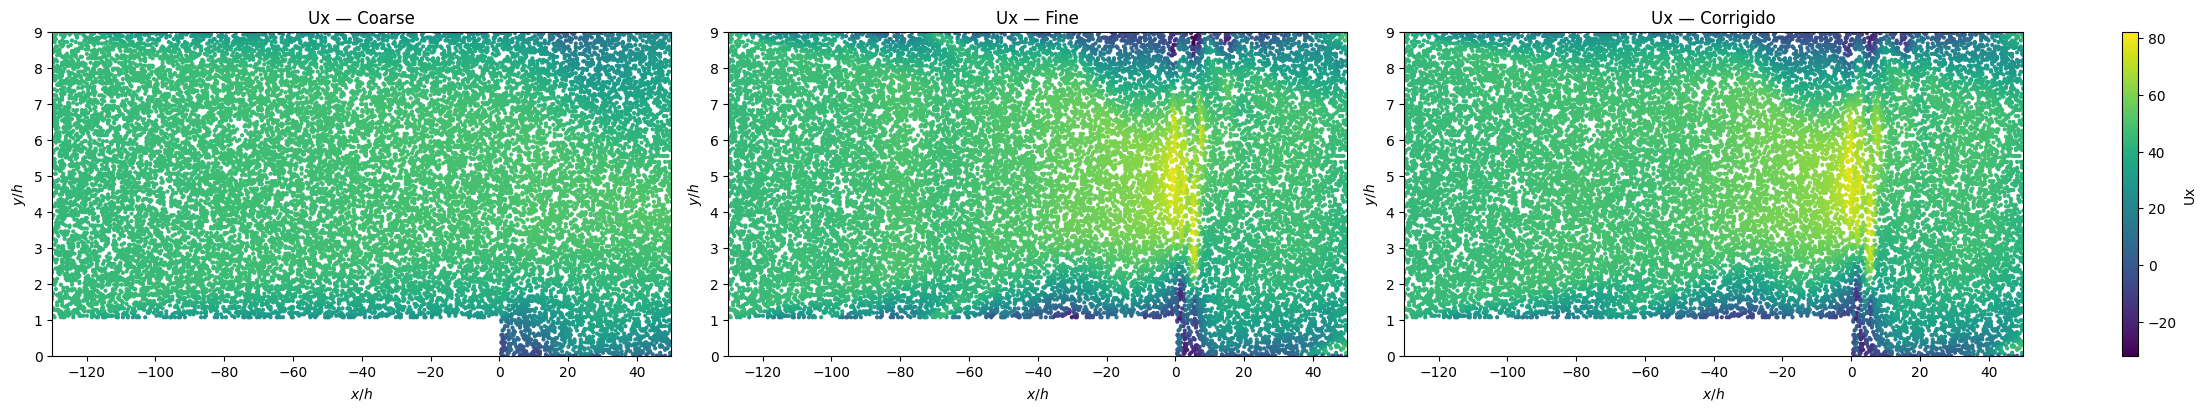

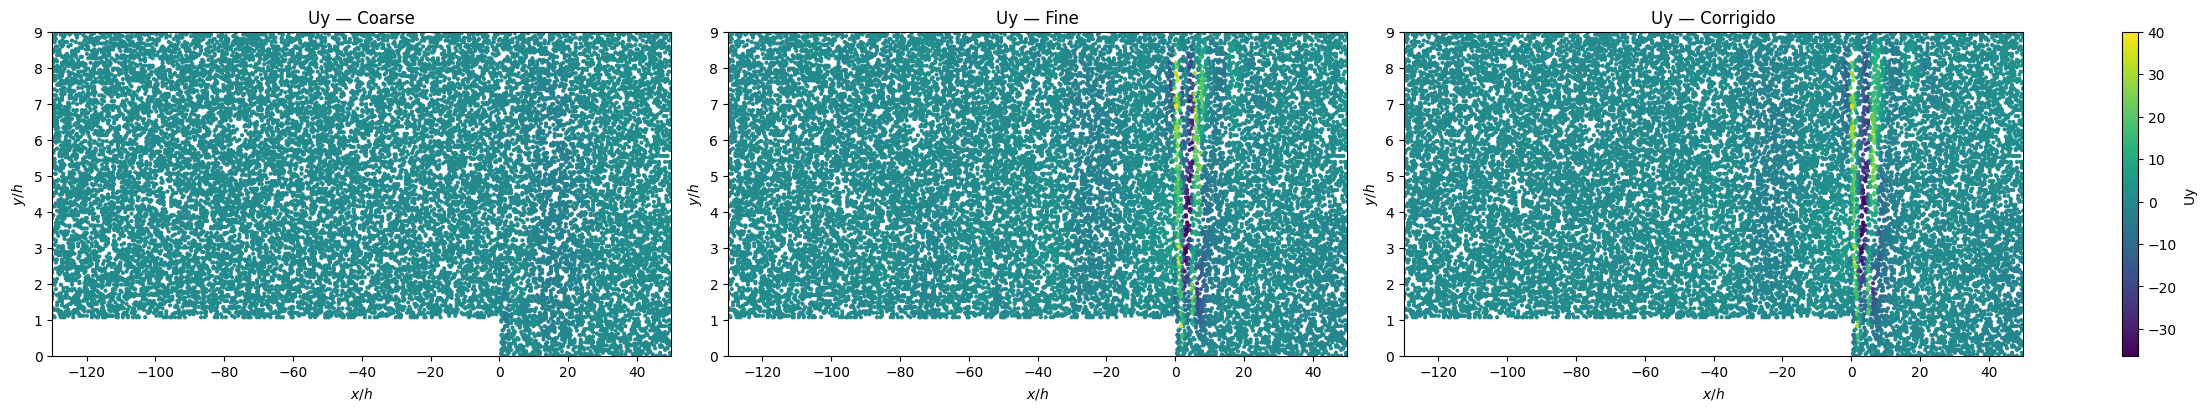

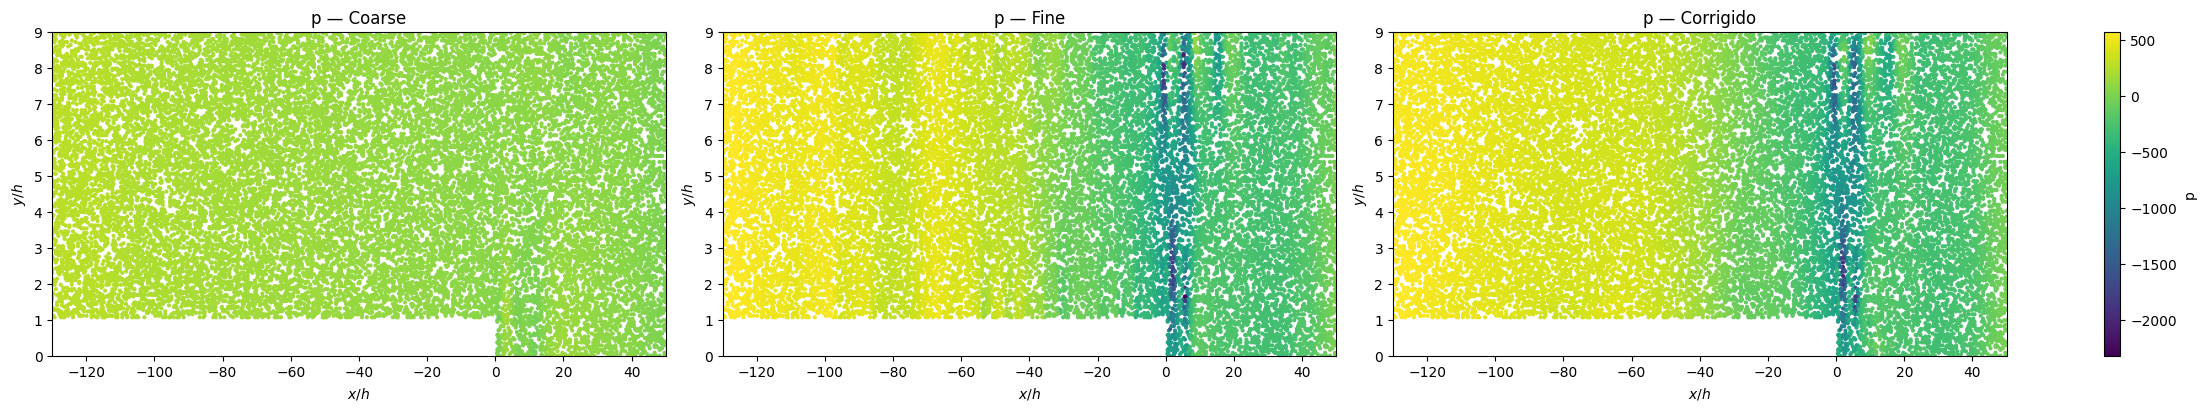


===== Métricas (PINN) =====
MAE vetorial (u,v) (coarse -> fine):      5.983332
MAE pressão (p) (coarse -> fine):         283.983856
MAE vetorial (u,v) (corrigido -> fine):   1.256078
MAE pressão (p) (corrigido -> fine):      29.745070
MAE vetorial (ΔU_pred -> ΔU_true):        1.256078
MAE pressão (Δp_pred -> Δp_true):         29.745070
RMSE (u,v) (coarse -> fine):              9.655787
RMSE (u,v) (corrigido -> fine):           2.320228
RMSE (p)   (coarse -> fine):              345.091797
RMSE (p)   (corrigido -> fine):           46.198132
RER (u,v):                                0.7901
RER (p):                                  0.8953
Melhora (u,v) (MAE):                      79.01%
Melhora (p) (MAE):                        89.53%

===== Métricas Físicas (PINN) =====
L2 relativo (u,v) - Coarse:               2.152128e-01
L2 relativo (u,v) - Corrigido:            5.171436e-02
L2 relativo (p) - Coarse:                 8.651386e-01
L2 relativo (p) - Corrigido:              1.158179e-01
S

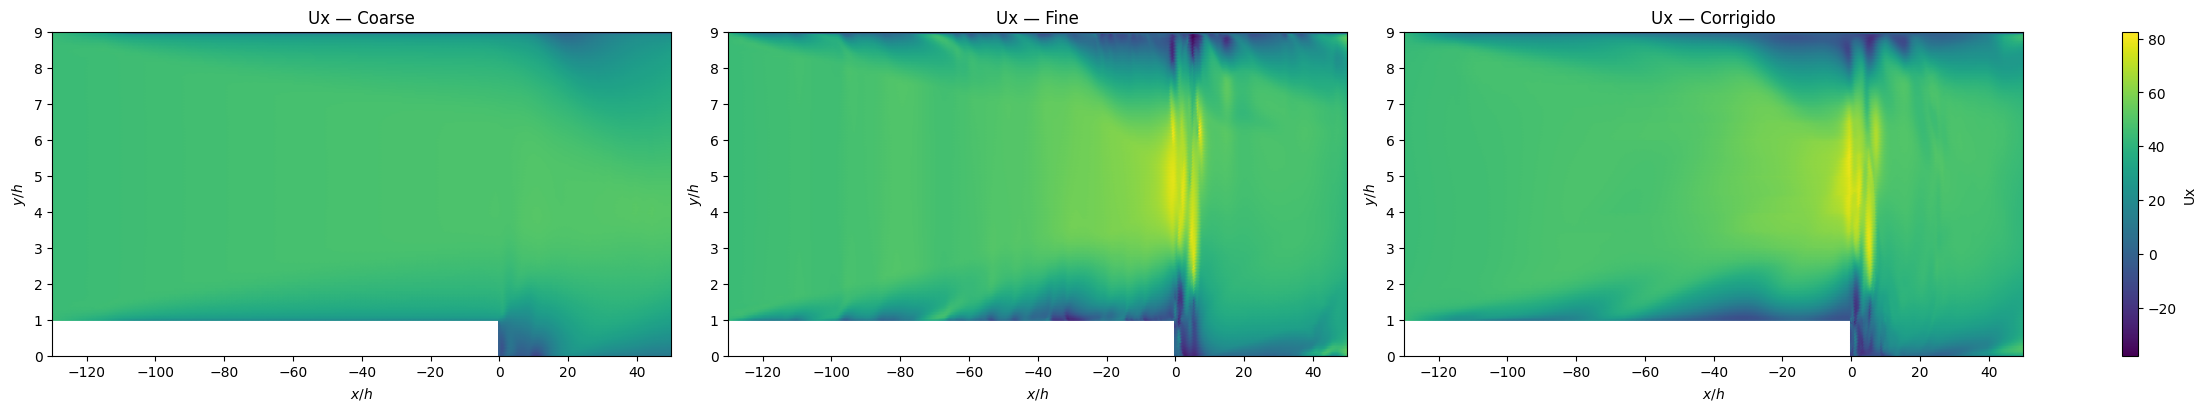

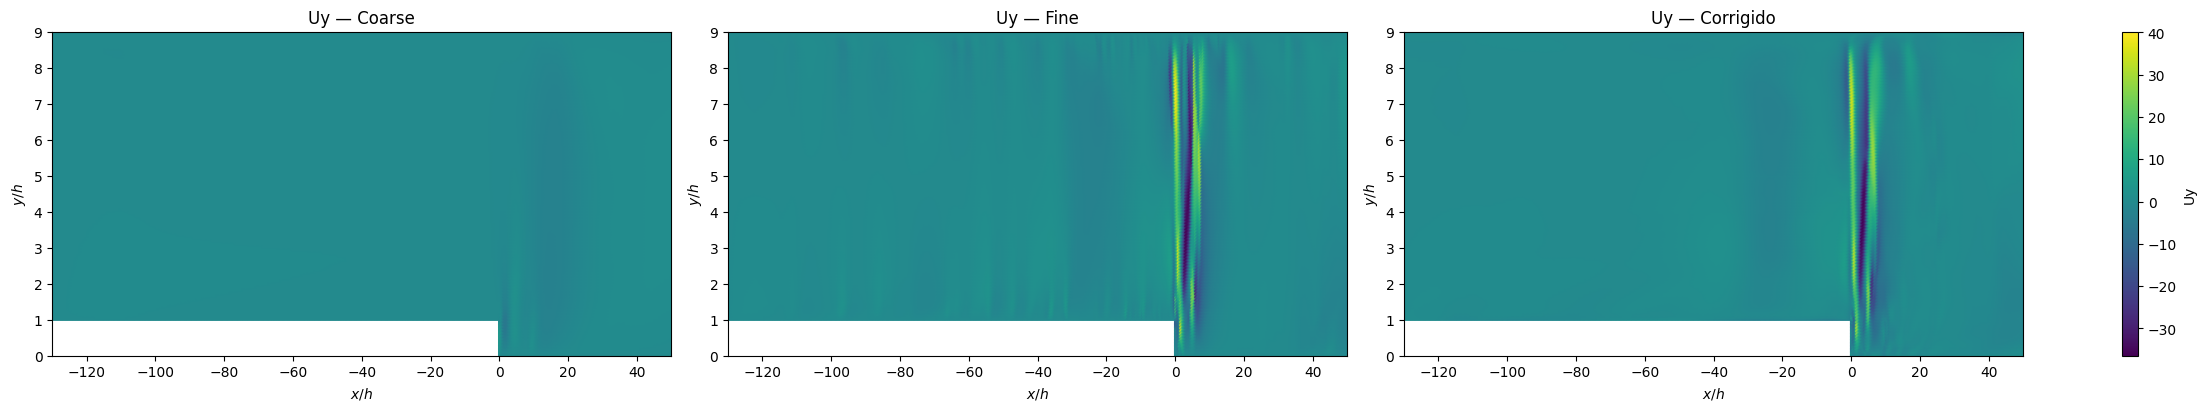

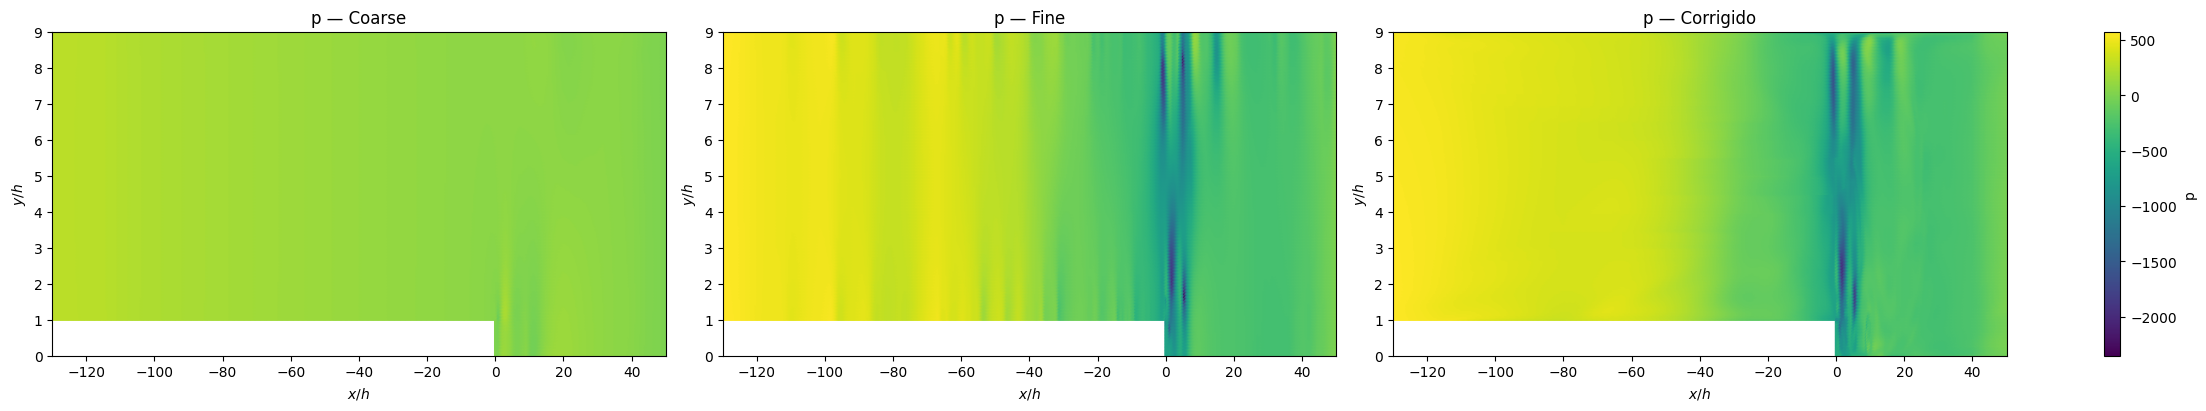


===== Métricas (PINN) =====
MAE vetorial (u,v) (coarse -> fine):      6.021581
MAE pressão (p) (coarse -> fine):         284.135254
MAE vetorial (u,v) (corrigido -> fine):   1.262934
MAE pressão (p) (corrigido -> fine):      29.435211
MAE vetorial (ΔU_pred -> ΔU_true):        1.262934
MAE pressão (Δp_pred -> Δp_true):         29.435215
RMSE (u,v) (coarse -> fine):              9.714196
RMSE (u,v) (corrigido -> fine):           2.319882
RMSE (p)   (coarse -> fine):              345.066864
RMSE (p)   (corrigido -> fine):           45.367115
RER (u,v):                                0.7903
RER (p):                                  0.8964
Melhora (u,v) (MAE):                      79.03%
Melhora (p) (MAE):                        89.64%

===== Métricas Físicas (PINN) =====
L2 relativo (u,v) - Coarse:               2.160798e-01
L2 relativo (u,v) - Corrigido:            5.160280e-02
L2 relativo (p) - Coarse:                 8.669747e-01
L2 relativo (p) - Corrigido:              1.139841e-01
S

{'mae_uv_coarse_to_fine': 6.021580696105957,
 'mae_uv_corrected_to_fine': 1.2629340887069702,
 'mae_uv_deltas_pred_vs_true': 1.2629340887069702,
 'mae_p_pressure_coarse_to_fine': 284.13525390625,
 'mae_p_corrected_to_fine': 29.435211181640625,
 'mae_p_deltas_pred_vs_true': 29.43521499633789,
 'rmse_uv_coarse_to_fine': 9.71419620513916,
 'rmse_uv_corrected_to_fine': 2.3198819160461426,
 'rmse_p_coarse_to_fine': 345.0668640136719,
 'rmse_p_corrected_to_fine': 45.36711502075195,
 'l2_rel_uv_coarse': 0.21607980132102966,
 'l2_rel_uv_corrected': 0.0516027957201004,
 'l2_rel_p_coarse': 0.8669746518135071,
 'l2_rel_p_corrected': 0.11398409307003021,
 'RER (u,v)': 0.7902653551544238,
 'RER (p)': 0.8964042272932713,
 'melhora_MAE_pct': 79.02653551544238,
 'melhora_MAE_pct_pressure': 89.64042272932713,
 'N': 100975}

In [79]:
# -----------------------------
# 4) Resíduos físicos (2D incompressível, estacionário)
# -----------------------------
def pde_residuals_continuity(x, y, u_coarse, v_coarse, model_out):
    """
    x, y: (N,1) leaf tensors com requires_grad=True (os mesmos do forward)
    model_out:
      se predict_dp=True: (N,3) = [dU, dV, dP]
      senão: (N,2) = [dU, dV]
    """

    dU, dV = model_out[:, [0]], model_out[:, [1]]

    u_hat = u_coarse + dU
    v_hat = v_coarse + dV

    # derivadas
    u_x = grad(u_hat, x)
    v_y = grad(v_hat, y)

    r_cont = u_x + v_y

    return r_cont

def boundary_loss_wall(df_phys, pred_phys, feat_index, h=0.0127, tol=1e-6):
    y = df_phys[:, [feat_index["y"]]]

    dU = pred_phys[:, [0]]
    dV = pred_phys[:, [1]]

    u_c = df_phys[:, [feat_index["Ux"]]]
    v_c = df_phys[:, [feat_index["Uy"]]]

    u_hat = u_c + dU
    v_hat = v_c + dV

    ymax = 9 * h

    mask_wall = (y <= tol) | (y >= ymax - tol)

    if mask_wall.sum() == 0:
        return torch.tensor(0.0, device=df_phys.device)

    loss_bc = (
        (u_hat[mask_wall] ** 2).mean()
        + (v_hat[mask_wall] ** 2).mean()
    )

    return loss_bc

FEAT_COLS = ["x", "y", "Ux", "Uy", "p", "k"]

# ajuste aqui se seus targets têm outros nomes
TARGET_COLS = ["dUx", "dUy", "dp"]  # (ΔUx_true, ΔUy_true)
HAS_TARGETS = True           # se quiser rodar sem supervisão, coloque False

# -----------------------------
# Função de Treino
# -----------------------------
def train_pinn(
    parquet_path,
    feat_cols,
    target_cols,
    has_target,
    batch_data=4096,
    batch_phys=4096,
    epochs_pre=50,
    epochs_phys=100,
    lr=1e-3,
    w_data=1.0,
    w_cont=1.0,
    w_bc=1.0,
    predict_dp=True,
    seed=42
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    df = pd.read_parquet(parquet_path)

    # Split simples (pode trocar por split espacial/estratificado por região de wz)
    n = len(df)
    idx = np.random.permutation(n)
    ntr = int(0.8 * n)
    tr_idx, te_idx = idx[:ntr], idx[ntr:]

    df_tr = df.iloc[tr_idx].reset_index(drop=True)
    df_te = df.iloc[te_idx].reset_index(drop=True)

    # Dataset supervisionado (dados)
    train_ds = CFDParquet(df_tr, feat_cols, target_cols if has_target else None)
    test_ds  = CFDParquet(df_te, feat_cols, target_cols if has_target else None,
                      x_scaler=(train_ds.x_mu, train_ds.x_sd), 
                      y_scaler=(train_ds.y_mu, train_ds.y_sd))


    dl_data = DataLoader(train_ds, batch_size=batch_data, shuffle=True, drop_last=True)

    in_dim = len(feat_cols)
    out_dim = 3 if predict_dp else 2
    net = MLP(in_dim=in_dim, out_dim=out_dim, width=128, depth=5, act=nn.Tanh).to(DEVICE)

    opt = torch.optim.Adam(net.parameters(), lr=lr)

    # helper: pegar colunas específicas do batch (já normalizado) e voltar pra escala original
    # aqui a gente precisa de x,y,Ux,Uy,p,Re em escala original pra PDE.
    feat_index = {c: i for i, c in enumerate(feat_cols)}

    x_mu = torch.as_tensor(train_ds.x_mu, dtype=DTYPE, device=DEVICE)
    x_sd = torch.as_tensor(train_ds.x_sd, dtype=DTYPE, device=DEVICE)
    y_mu = torch.as_tensor(train_ds.y_mu, dtype=DTYPE, device=DEVICE)
    y_sd = torch.as_tensor(train_ds.y_sd, dtype=DTYPE, device=DEVICE)

    def unnormalize_X(Xn):
        return Xn * x_sd + x_mu
    
    def denorm_y(yn, y_mu, y_sd):
        return yn * y_sd + y_mu

    # ---- STAGE 1: pré-treino supervisionado (dados)
    if has_target and epochs_pre > 0:
        net.train()
        for ep in range(1, epochs_pre + 1):
            total = 0.0
            for Xn, Yn in dl_data:
                Xn = Xn.to(DEVICE)
                Yn = Yn.to(DEVICE)

                pred = net(Xn)
                loss = torch.mean((pred - Yn) ** 2) 

                opt.zero_grad()
                loss.backward()
                opt.step()

                total += loss.item()

            if ep % 10 == 0 or ep == 1:
                print(f"[PRE] ep={ep:03d} loss_data={total/len(dl_data):.6e}")

    # ---- STAGE 2: dados + física (REFATORADO / SEM detach no caminho de x,y)
    net.train()
    for ep in range(1, epochs_phys + 1):
        total_loss = 0.0
        total_data = 0.0
        total_bc = 0.0
        total_cont = 0.0

        for batch in dl_data:
            if has_target:
                Xn, Yn = batch
                Xn = Xn.to(DEVICE)
                Yn = Yn.to(DEVICE)
            else:
                Xn = batch
                Xn = Xn.to(DEVICE)
                Yn = None

            # =========================
            # (1) Loss de dados (ΔU)
            # =========================
            pred_data = net(Xn)  # forward normal
            loss_data = torch.tensor(0.0, device=DEVICE)
            if has_target:
                loss_data = torch.mean((pred_data - Yn) ** 2)   # pred_data é (N,3) e Yn é (N,3)

            # ==========================================
            # (2) Loss física: x,y precisam estar no grafo
            #     então refazemos o forward com x,y requires_grad=True
            # ==========================================
            # Volta para escala física SEM detach (mantém as operações no grafo)
            # valores físicos só pra “montar” o input do PINN (não precisa de grad aqui)
            X_phys = unnormalize_X(Xn).detach() # (N, in_dim) em escala original

            # Cria x,y como tensores do grafo (folhas) para autodiff
            x = X_phys[:, [feat_index["x"]]].clone().requires_grad_(True)
            y = X_phys[:, [feat_index["y"]]].clone().requires_grad_(True)

            # Reinjeta x,y no vetor físico e renormaliza
            X_phys_mod = X_phys.clone()
            X_phys_mod[:, [feat_index["x"]]] = x
            X_phys_mod[:, [feat_index["y"]]] = y

            Xn_mod = (X_phys_mod - x_mu) / x_sd

            # Forward "physics-aware"
            pred_phys_n = net(Xn_mod)
            pred_phys = pred_phys_n * y_sd + y_mu

            # Campos coarse (em escala física) para montar o campo corrigido
            u_c = X_phys[:, [feat_index["Ux"]]]
            v_c = X_phys[:, [feat_index["Uy"]]]
            p_c = X_phys[:, [feat_index["p"]]]


            # Resíduo de continuidade PINN)
            r_cont = pde_residuals_continuity(
                x=x,
                y=y,
                u_coarse=u_c,
                v_coarse=v_c,
                model_out=pred_phys
            )
            loss_bc = boundary_loss_wall(
                df_phys=X_phys,
                pred_phys=pred_phys,
                feat_index=feat_index,
                h=0.0127
            )
            loss_cont = (r_cont ** 2).mean()
            loss = (
                w_data * loss_data
                + w_cont * loss_cont
                + w_bc * loss_bc
            )

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            total_loss += loss.item()
            total_data += loss_data.item()
            total_bc += loss_bc.item()
            total_cont += loss_cont.item()

        if ep % 10 == 0 or ep == 1:
            n_batches = len(dl_data)
            print(
                f"[PINN] ep={ep:03d} "
                f"loss={total_loss/n_batches:.6e} "
                f"data={total_data/n_batches:.3e} "
                f"bc={total_bc/n_batches:.3e} "
                f"cont={total_cont/n_batches:.3e}"
            )


    return net, (train_ds.x_mu, train_ds.x_sd), (train_ds.y_mu, train_ds.y_sd)


# -------------------------------
# Funções de Avaliação / Métricas
# -------------------------------
@torch.no_grad()
def evaluate_pinn_physical(
    model, parquet_test_path, feat_cols, xscaler, yscaler,
    batch_size=4900, out_json=PATH_OUT / "metrics_pinn_cont_0.001.json"
):

    model.eval()
    device = next(model.parameters()).device

    df = pd.read_parquet(parquet_test_path)

    Ux_c = df["Ux"].to_numpy(np.float32)
    Uy_c = df["Uy"].to_numpy(np.float32)
    p_c  = df["p"].to_numpy(np.float32)

    dUx_true = df["dUx"].to_numpy(np.float32)
    dUy_true = df["dUy"].to_numpy(np.float32)
    dp_true  = df["dp"].to_numpy(np.float32)

    Ux_f = Ux_c + dUx_true
    Uy_f = Uy_c + dUy_true
    p_f  = p_c  + dp_true

    X = df[feat_cols].to_numpy(np.float32)
    x_mu, x_sd = xscaler
    y_mu, y_sd = yscaler
    Xn = (X - x_mu) / x_sd

    dUx_pred = np.zeros(len(df), dtype=np.float32)
    dUy_pred = np.zeros(len(df), dtype=np.float32)
    dp_pred = np.zeros(len(df), dtype=np.float32)
    
    for i0 in range(0, len(df), batch_size):
        i1 = min(i0 + batch_size, len(df))
        xb = torch.tensor(Xn[i0:i1], dtype=torch.float32, device=device)
        out_n = model(xb)[:, :3].detach().cpu().numpy()
        out = out_n * y_sd + y_mu
        dUx_pred[i0:i1] = out[:, 0]
        dUy_pred[i0:i1] = out[:, 1]
        dp_pred[i0:i1] = out[:, 2]

    Ux_hat = Ux_c + dUx_pred
    Uy_hat = Uy_c + dUy_pred
    p_hat = p_c + dp_pred

    # Plotagem comparativa dos perfis de velocidade e pressão
    pred_df = df[["x", "y", "Ux", "Uy", "p", "dUx", "dUy", "dp"]].copy()

    pred_df["Ux_f"] = pred_df["Ux"] + pred_df["dUx"]
    pred_df["Uy_f"] = pred_df["Uy"] + pred_df["dUy"]
    pred_df["p_f"]  = pred_df["p"]  + pred_df["dp"]

    pred_df["dUx_pred"] = dUx_pred
    pred_df["dUy_pred"] = dUy_pred
    pred_df["dp_pred"]  = dp_pred

    pred_df["Ux_corr"] = pred_df["Ux"] + pred_df["dUx_pred"]
    pred_df["Uy_corr"] = pred_df["Uy"] + pred_df["dUy_pred"]
    pred_df["p_corr"]  = pred_df["p"]  + pred_df["dp_pred"]

    plot_field_compare(pred_df, "Ux", "Ux_f", "Ux_corr", "Ux")
    plot_field_compare(pred_df, "Uy", "Uy_f", "Uy_corr", "Uy")
    plot_field_compare(pred_df, "p", "p_f", "p_corr", "p")

    def mae_vec(u1, v1, u2, v2):
        return float(np.mean(np.sqrt((u1 - u2)**2 + (v1 - v2)**2)))
    
    def mae_vec_pressure(p1, p2):
        return float(np.mean(np.abs(p1 - p2)))
    
    def rmse_uv(u1, v1, u2, v2):
        return float(np.sqrt(np.mean((u1-u2)**2 + (v1-v2)**2)))

    def rmse_p(p1, p2):
        return float(np.sqrt(np.mean((p1-p2)**2)))
    
    def l2_relative_uv(u_pred, v_pred, u_ref, v_ref):
        num = np.sqrt(np.sum((u_pred - u_ref)**2 + (v_pred - v_ref)**2))
        den = np.sqrt(np.sum(u_ref**2 + v_ref**2))
        return float(num / (den + 1e-12))

    def l2_relative_p(p_pred, p_ref):
        num = np.linalg.norm(p_pred - p_ref)
        den = np.linalg.norm(p_ref)
        return float(num / (den + 1e-12))
    
    #MAE
    mae_coarse = mae_vec(Ux_c, Uy_c, Ux_f, Uy_f)
    mae_p_coarse = mae_vec_pressure(p_c, p_f)
    mae_corr   = mae_vec(Ux_hat, Uy_hat, Ux_f, Uy_f)
    mae_p_corr = mae_vec_pressure(p_hat, p_f)
    mae_deltas = mae_vec(dUx_pred, dUy_pred, dUx_true, dUy_true)
    mae_deltas_p = mae_vec_pressure(dp_pred, dp_true)
    #RMSE
    rmse_uv_coarse = rmse_uv(Ux_c, Uy_c, Ux_f, Uy_f)
    rmse_uv_corr = rmse_uv(Ux_hat, Uy_hat, Ux_f, Uy_f)
    rmse_p_coarse = rmse_p(p_c, p_f)
    rmse_p_corr = rmse_p(p_hat, p_f)
    #RER
    rer_uv = 1.0 - (mae_corr / (mae_coarse + 1e-12))
    melhora_pct_uv = rer_uv * 100.0
    rer_p = 1.0 - (mae_p_corr / (mae_p_coarse + 1e-12))
    melhora_pct_p = rer_p * 100.0
    #L2
    l2_coarse_uv = l2_relative_uv(Ux_c, Uy_c, Ux_f, Uy_f)
    l2_corr_uv   = l2_relative_uv(Ux_hat, Uy_hat, Ux_f, Uy_f)
    l2_coarse_p = l2_relative_p(p_c, p_f)
    l2_corr_p   = l2_relative_p(p_hat, p_f)

    metrics = {
        "mae_uv_coarse_to_fine": mae_coarse,
        "mae_uv_corrected_to_fine": mae_corr,
        "mae_uv_deltas_pred_vs_true": mae_deltas,
        "mae_p_pressure_coarse_to_fine": mae_p_coarse,
        "mae_p_corrected_to_fine": mae_p_corr,
        "mae_p_deltas_pred_vs_true": mae_deltas_p,
        "rmse_uv_coarse_to_fine": rmse_uv_coarse,
        "rmse_uv_corrected_to_fine": rmse_uv_corr,
        "rmse_p_coarse_to_fine": rmse_p_coarse,
        "rmse_p_corrected_to_fine": rmse_p_corr,
        "l2_rel_uv_coarse": l2_coarse_uv,
        "l2_rel_uv_corrected": l2_corr_uv,
        "l2_rel_p_coarse": l2_coarse_p,
        "l2_rel_p_corrected": l2_corr_p,
        "RER (u,v)": float(rer_uv),
        "RER (p)": float(rer_p),
        "melhora_MAE_pct": float(melhora_pct_uv),
        "melhora_MAE_pct_pressure": float(melhora_pct_p),
        "N": int(len(df)),
    }

    with open(out_json, "w") as f:
        json.dump(metrics, f, indent=2)

    print("\n===== Métricas (PINN) =====")
    print(f"MAE vetorial (u,v) (coarse -> fine):      {mae_coarse:.6f}")
    print(f"MAE pressão (p) (coarse -> fine):         {mae_p_coarse:.6f}")
    print(f"MAE vetorial (u,v) (corrigido -> fine):   {mae_corr:.6f}")
    print(f"MAE pressão (p) (corrigido -> fine):      {mae_p_corr:.6f}")
    print(f"MAE vetorial (ΔU_pred -> ΔU_true):        {mae_deltas:.6f}")
    print(f"MAE pressão (Δp_pred -> Δp_true):         {mae_deltas_p:.6f}")
    print(f"RMSE (u,v) (coarse -> fine):              {rmse_uv_coarse:.6f}")
    print(f"RMSE (u,v) (corrigido -> fine):           {rmse_uv_corr:.6f}")
    print(f"RMSE (p)   (coarse -> fine):              {rmse_p_coarse:.6f}")
    print(f"RMSE (p)   (corrigido -> fine):           {rmse_p_corr:.6f}")
    print(f"RER (u,v):                                {rer_uv:.4f}")
    print(f"RER (p):                                  {rer_p:.4f}")
    print(f"Melhora (u,v) (MAE):                      {melhora_pct_uv:.2f}%")
    print(f"Melhora (p) (MAE):                        {melhora_pct_p:.2f}%")

    print("\n===== Métricas Físicas (PINN) =====")
    print(f"L2 relativo (u,v) - Coarse:               {l2_coarse_uv:.6e}")
    print(f"L2 relativo (u,v) - Corrigido:            {l2_corr_uv:.6e}")
    print(f"L2 relativo (p) - Coarse:                 {l2_coarse_p:.6e}")
    print(f"L2 relativo (p) - Corrigido:              {l2_corr_p:.6e}")
    print(f"Salvo: {out_json}\n")


    return metrics


# ---------------------------------
# Treinar o PINN corretor e avaliar
# ---------------------------------

FEAT_COLS = ["x", "y", "Ux", "Uy", "p", "k", "nut_log","Re"]

# ajuste aqui se seus targets têm outros nomes
TARGET_COLS = ["dUx", "dUy", "dp"]  # (ΔUx_true, ΔUy_true)
HAS_TARGETS = True           # se quiser rodar sem supervisão, coloque False

model, xscaler, yscaler= train_pinn(
    parquet_path=PATH_DATA / "dataset_bfs_2d_kepsilon_with_wz.parquet",
    feat_cols=FEAT_COLS,
    target_cols=TARGET_COLS,
    has_target=HAS_TARGETS,
    epochs_pre=300,
    epochs_phys=300,
    lr=1e-4,
    w_data=1.0,
    w_cont=1e-4,
    w_bc=1e-5,
    predict_dp=True
)

# salvar modelo e scalers
torch.save({"state_dict": model.state_dict(), "xscaler": xscaler}, PATH_MODEL / "pinn_corrector_cont_bc_kepsilon.pt")
joblib.dump(xscaler, PATH_OUT / "pinn_scaler_X.pkl")
joblib.dump(yscaler, PATH_OUT / "pinn_scaler_Y.pkl")
print("Salvo scalers da PINN!")

# Avaliação no dataset de TESTE
print("###############################################################")
print("################### Avaliação Dataset Teste ###################")
print("###############################################################")
evaluate_pinn_physical(
    model=model,
    parquet_test_path=PATH_DATA / "dataset_test_pinn_with_wz.parquet",
    feat_cols=FEAT_COLS,
    xscaler=xscaler,
    yscaler=yscaler,
    out_json=PATH_OUT / "metrics_test_pinn_cont_bc_1e-04_with_wz.json"
)

# Avaliação no dataset COMPLETO
print("##################################################################")
print("################### Avaliação Dataset Completo ###################")
print("##################################################################")
evaluate_pinn_physical(
    model=model,
    parquet_test_path=PATH_DATA / "dataset_bfs_2d_kepsilon.parquet",
    feat_cols=FEAT_COLS,
    xscaler=xscaler,
    yscaler=yscaler,
    out_json=PATH_OUT / "metrics_full_pinn_cont_bc_1e-04.json"
)